In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/titanic/train.csv
/kaggle/input/titanic/test.csv
/kaggle/input/titanic/gender_submission.csv


# EDA

## 1. Loading Packages

In [2]:
import numpy as np
import pandas as pd

import random
random.seed(28)
np.random.seed(28)


import matplotlib.pyplot as plt
from sklearn.metrics import (confusion_matrix, precision_recall_curve, auc,
                             roc_curve, recall_score, classification_report, f1_score,
                             precision_recall_fscore_support)
import os
import copy
from sklearn.metrics import mean_absolute_error
pd.options.display.precision = 15
from collections import defaultdict
import lightgbm as lgb
import xgboost as xgb
import catboost as cat
import time
from collections import Counter
import datetime
from catboost import CatBoostRegressor
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import StratifiedKFold, KFold, RepeatedKFold, GroupKFold, GridSearchCV, train_test_split, TimeSeriesSplit, RepeatedStratifiedKFold
from sklearn import metrics
import gc
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
from bayes_opt import BayesianOptimization
import eli5
import shap
from IPython.display import HTML
import json

import matplotlib.pyplot as plt
%matplotlib inline
import os
import time
import datetime
import gc
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn import metrics
pd.set_option('max_rows', 500)
import re

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

pd.set_option('display.max_columns', 1000)
np.random.seed(566)
pd.set_option('display.max_rows', 500)
pd.set_option('display.width', 1000)
pd.set_option('display.float_format', '{:20,.2f}'.format)
pd.set_option('display.max_colwidth', -1)

/kaggle/input/titanic/train.csv
/kaggle/input/titanic/test.csv
/kaggle/input/titanic/gender_submission.csv


## 2. Loading Data & Basic Analysis

In [3]:
test=pd.read_csv("../input/titanic/test.csv")
test.set_index("PassengerId",inplace=True)
test['Data']="Test"
train=pd.read_csv("../input/titanic/train.csv")
train.set_index("PassengerId",inplace=True)
train['Data']="Train"
samplesubmission = pd.read_csv("../input/titanic/gender_submission.csv")

In [4]:
print('train ' , train.shape)
print('test ' , test.shape)
print('samplesubmission ' , samplesubmission.shape)

train  (891, 12)
test  (418, 11)
samplesubmission  (418, 2)


In [5]:
df=train.append(test)
df.head(2)

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Data
PassengerId,,,,,,,,,,,,
1,0.00,3,"Braund, Mr. Owen Harris",male,22.00,1,0,A/5 21171,7.25,NaN,S,Train
2,1.00,1,"Cumings, Mrs. John Bradley (Florence Briggs Thayer)",female,38.00,1,0,PC 17599,71.28,C85,C,Train


In [6]:
print('Merged Dataframe' , df.shape)

Merged Dataframe (1309, 12)


## Have a look at missing value

<AxesSubplot:>

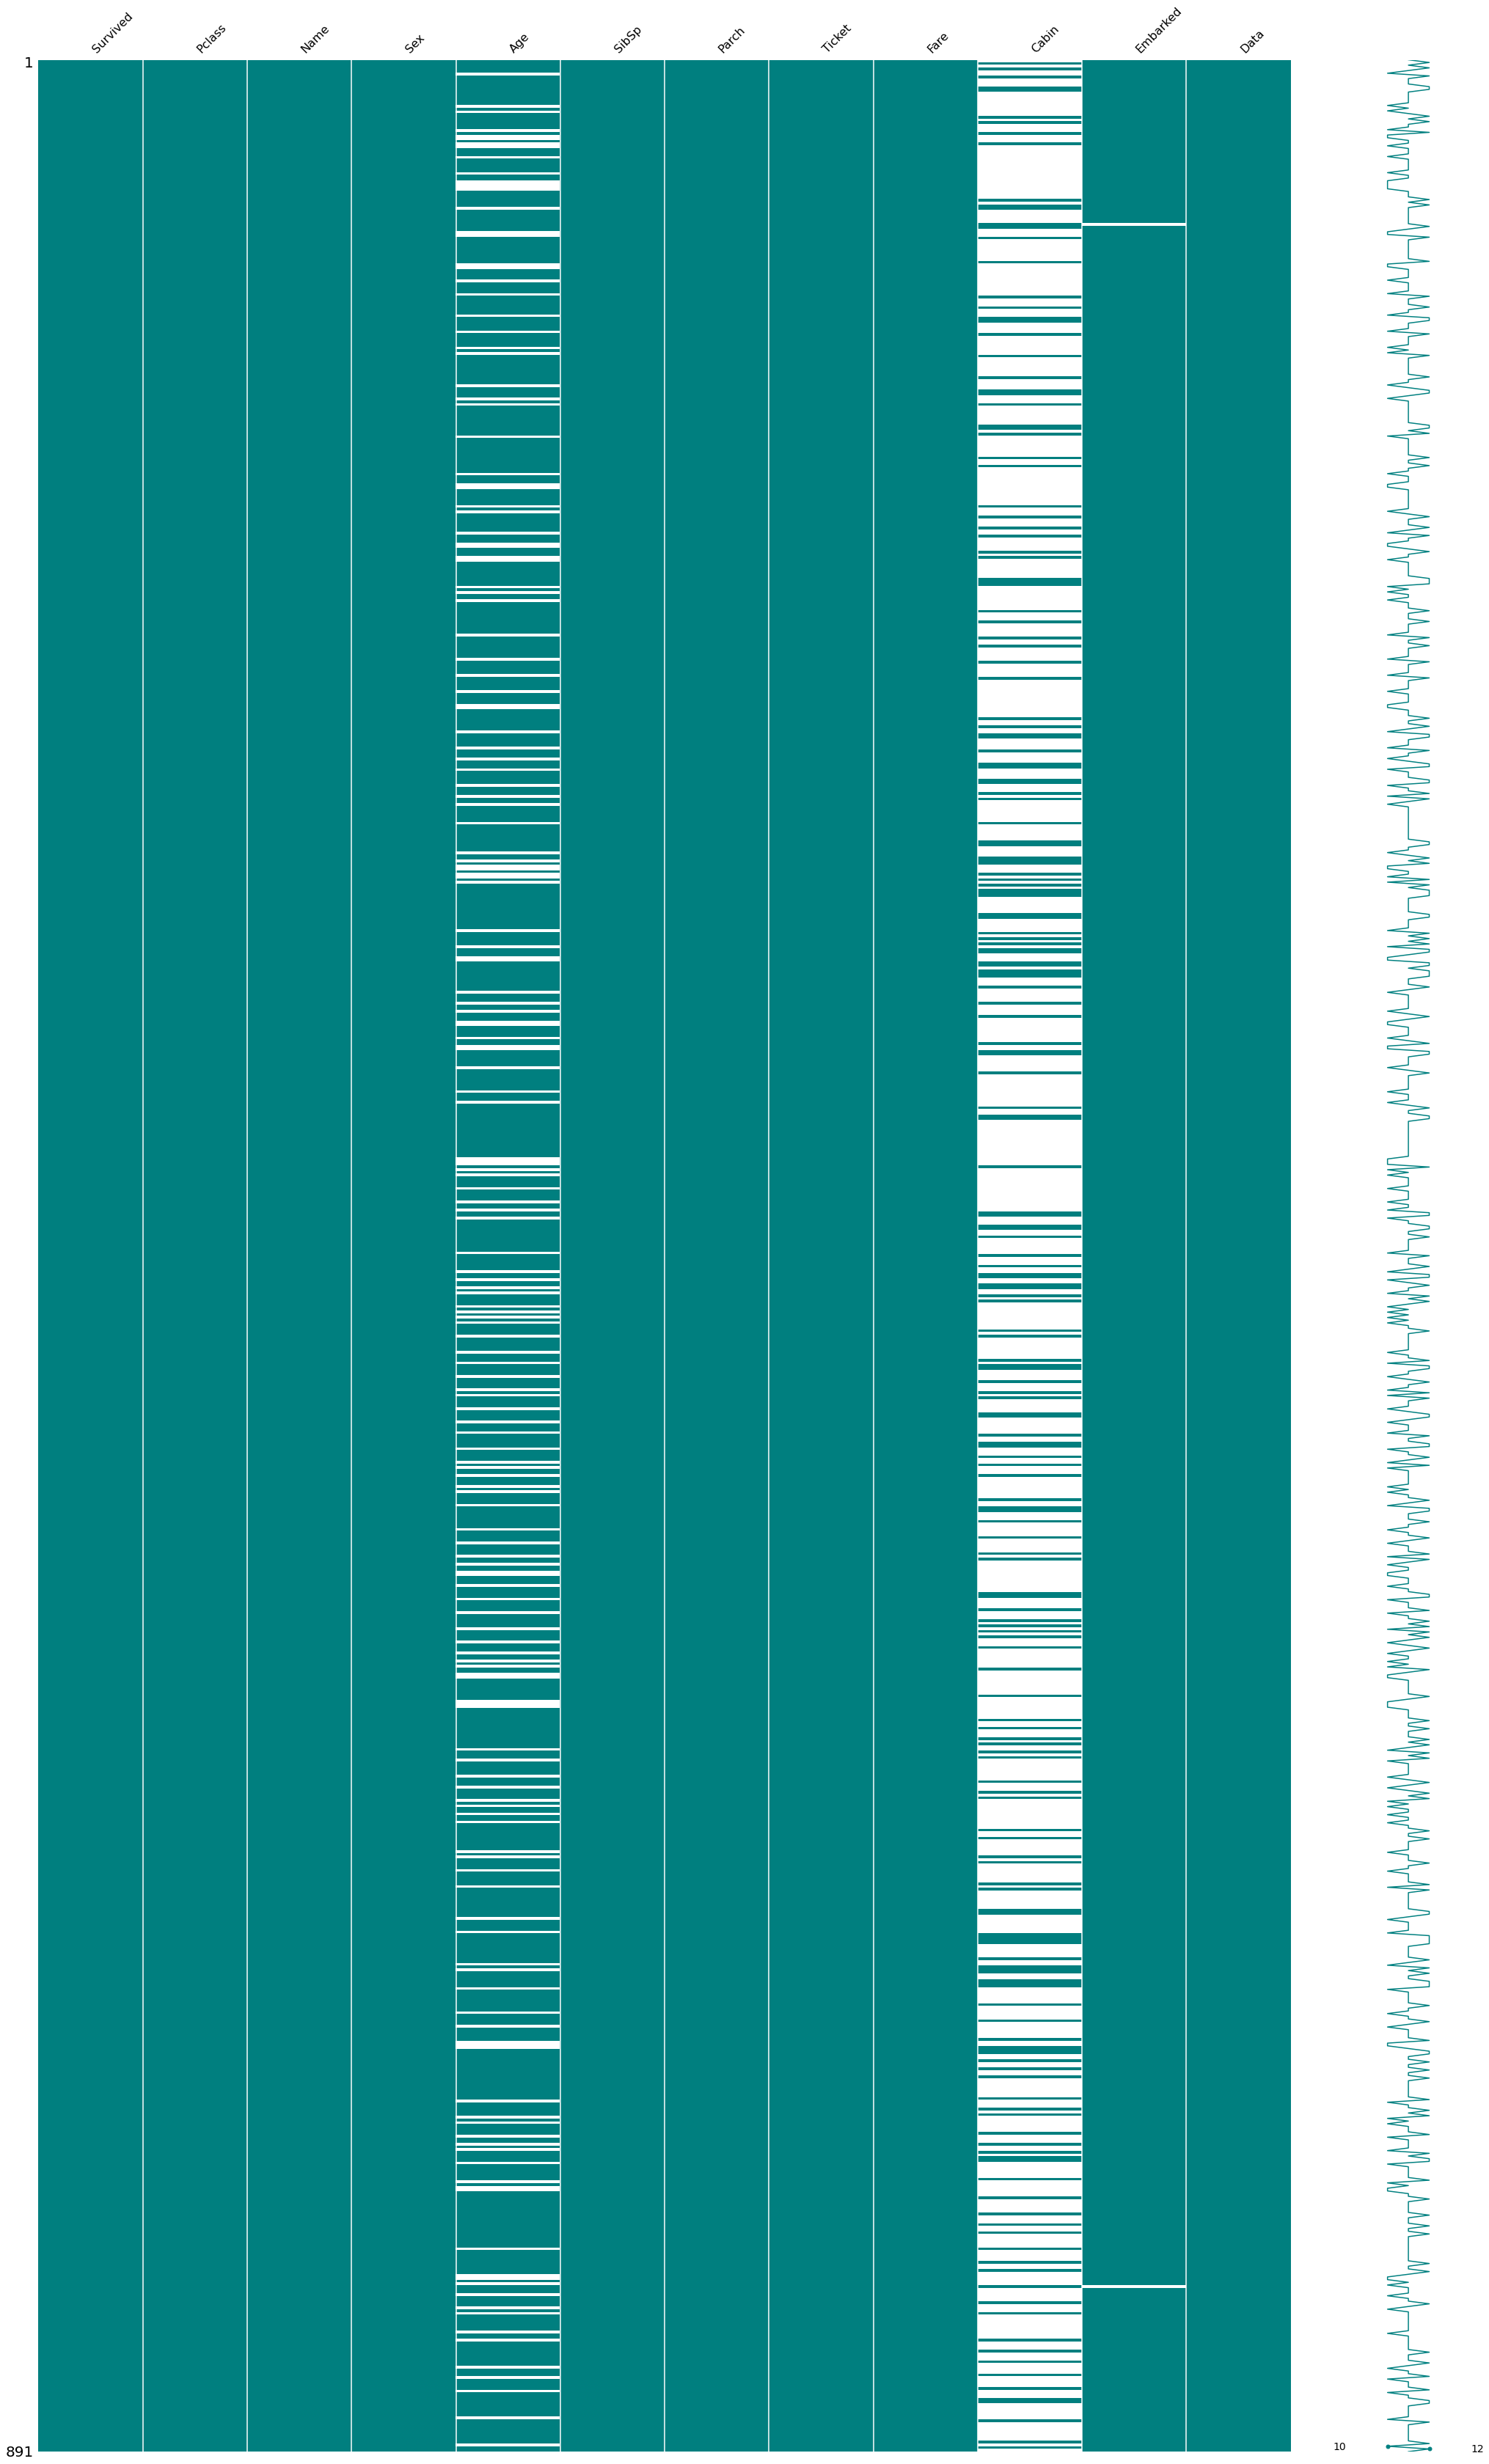

In [7]:
import missingno as msno
%matplotlib inline
msno.matrix(train,figsize=(35, 60), 
            width_ratios=(10, 1), color=(.0, 0.5, 0.5),
            fontsize=16)

In [8]:
# Define a function to visulize the features with missing values, and % of total values, & datatype
def missing_values_table(df):
     # Total missing values
    mis_val = df.isnull().sum()
    # Percentage of missing values
    mis_val_percent = 100 * df.isnull().sum() / len(df)
    mis_val_type = df.dtypes
    # Make a table with the results
    mis_val_table = pd.concat([mis_val, mis_val_percent, mis_val_type], axis=1)
        
     # Rename the columns
    mis_val_table_ren_columns = mis_val_table.rename(columns = {0 : 'Missing Values', 1 : '% of Total Values', 2: 'type'})
        
    # Sort the table by percentage of missing descending
    mis_val_table_ren_columns = mis_val_table_ren_columns[ mis_val_table_ren_columns.iloc[:,1] != 0].sort_values('% of Total Values', ascending=False).round(1)
        
    # Print some summary information
    print ("Your selected dataframe has " + str(df.shape[1]) + " columns.\n" "There are " + str(mis_val_table_ren_columns.shape[0]) + " columns that have missing values.")
        
    # Return the dataframe with missing information
    return mis_val_table_ren_columns

In [9]:
missing_values_table(df)

Your selected dataframe has 12 columns.
There are 5 columns that have missing values.


,Missing Values,% of Total Values,type
Cabin,1014,77.50,object
Survived,418,31.90,float64
Age,263,20.10,float64
Embarked,2,0.20,object
Fare,1,0.10,float64


In [10]:
#pct_null = df.isnull().sum() / len(df) 
#missing_features = pct_null[pct_null > 0.50].index 
#df.drop(missing_features, axis=1, inplace=True)

In [11]:
df['Fare'] = df['Fare'].fillna(0)
df["Embarked"] = df["Embarked"].fillna('C')
missing_values_table(df)

Your selected dataframe has 12 columns.
There are 3 columns that have missing values.


,Missing Values,% of Total Values,type
Cabin,1014,77.50,object
Survived,418,31.90,float64
Age,263,20.10,float64


In [12]:
#Fill missing values in Fare
df.loc[(df['Fare'] == 0) & (df['Pclass'] == 1), 'Fare'] = df[df['Pclass'] == 1]['Fare'].mean()
df.loc[(df['Fare'] == 0) & (df['Pclass'] == 2), 'Fare'] = df[df['Pclass'] == 2]['Fare'].mean()
df.loc[(df['Fare'] == 0) & (df['Pclass'] == 3), 'Fare'] = df[df['Pclass'] == 3]['Fare'].mean()

In [13]:
bins = np.linspace(min(df['Fare']), max(df['Fare']),6)
Group_name=['Very Low','Low','Medium','High', 'Very High']
df['FareCat']=pd.cut(df['Fare'], bins, labels=Group_name, include_lowest=True)
df.head()

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Data,FareCat
PassengerId,,,,,,,,,,,,,
1,0.00,3,"Braund, Mr. Owen Harris",male,22.00,1,0,A/5 21171,7.25,NaN,S,Train,Very Low
2,1.00,1,"Cumings, Mrs. John Bradley (Florence Briggs Thayer)",female,38.00,1,0,PC 17599,71.28,C85,C,Train,Very Low
3,1.00,3,"Heikkinen, Miss. Laina",female,26.00,0,0,STON/O2. 3101282,7.92,NaN,S,Train,Very Low
4,1.00,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.00,1,0,113803,53.10,C123,S,Train,Very Low
5,0.00,3,"Allen, Mr. William Henry",male,35.00,0,0,373450,8.05,NaN,S,Train,Very Low


In [14]:
df['Cabin'] = df['Cabin'].fillna("Missing")
#df['Age'] = df['Age'].fillna(df['Age'].mean())
df['CabinType'] = df['Cabin'].str[0]
df.drop('Cabin', axis=1, inplace=True)

In [15]:
missing_values_table(df)

Your selected dataframe has 13 columns.
There are 2 columns that have missing values.


,Missing Values,% of Total Values,type
Survived,418,31.90,float64
Age,263,20.10,float64


## Extracting & Analyzing Titles

In [16]:
import re
df['Title'] = df['Name'].apply(lambda x: re.search(' ([A-Z][a-z]+)\.', x).group(1))
df.head()

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Data,FareCat,CabinType,Title
PassengerId,,,,,,,,,,,,,,
1,0.00,3,"Braund, Mr. Owen Harris",male,22.00,1,0,A/5 21171,7.25,S,Train,Very Low,M,Mr
2,1.00,1,"Cumings, Mrs. John Bradley (Florence Briggs Thayer)",female,38.00,1,0,PC 17599,71.28,C,Train,Very Low,C,Mrs
3,1.00,3,"Heikkinen, Miss. Laina",female,26.00,0,0,STON/O2. 3101282,7.92,S,Train,Very Low,M,Miss
4,1.00,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.00,1,0,113803,53.10,S,Train,Very Low,C,Mrs
5,0.00,3,"Allen, Mr. William Henry",male,35.00,0,0,373450,8.05,S,Train,Very Low,M,Mr


___Dividing Titles into bigger categories___

The term *Mademoiselle* is a French familiar title, abbreviated **Mlle**, traditionally given to an unmarried woman. The equivalent in English is "Miss". However, the courtesy title "Madame" is accorded women where their marital status is unknown.

In [17]:
df['Title'] = df['Title'].replace('Mlle', 'Miss')

In France, one traditionally calls a young, unmarried woman Mademoiselle – Mlle for short – and an older, married woman _Madame_, whose abbreviation is **Mme**.

In [18]:
df['Title'] = df['Title'].replace('Mme', 'Mrs')

In [19]:
i = df[~df['Title'].isin(['Mr', 'Mrs', 'Miss', 'Master'])].index
df.loc[i, 'Title'] = 'Rare Title'
df['Title'].unique()

array(['Mr', 'Mrs', 'Miss', 'Master', 'Rare Title'], dtype=object)

In [20]:
for t in df['Title'].unique():
    for p in df['Pclass'].unique():
        df.loc[(df['Title'] == t) & (df['Pclass'] == p) & (df['Age'].isnull()), 'Age'] = df.loc[(df['Title'] == t) & (df['Pclass'] == p), 'Age'].median()

In [21]:
bins = np.linspace(min(df['Age']), max(df['Age']),6)
Group_name=['Very Low','Low','Medium','High', 'Very High']
df['AgeCat']=pd.cut(df['Age'], bins, labels=Group_name, include_lowest=True)
df.head(2)

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Data,FareCat,CabinType,Title,AgeCat
PassengerId,,,,,,,,,,,,,,,
1,0.00,3,"Braund, Mr. Owen Harris",male,22.00,1,0,A/5 21171,7.25,S,Train,Very Low,M,Mr,Low
2,1.00,1,"Cumings, Mrs. John Bradley (Florence Briggs Thayer)",female,38.00,1,0,PC 17599,71.28,C,Train,Very Low,C,Mrs,Medium


In [22]:
df_dummies = pd.get_dummies(df.AgeCat, prefix="AgeCat", drop_first=True)
df=pd.concat([df,df_dummies], axis=1)
df.drop("AgeCat", axis=1, inplace=True)
df.head(2)

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Data,FareCat,CabinType,Title,AgeCat_Low,AgeCat_Medium,AgeCat_High,AgeCat_Very High
PassengerId,,,,,,,,,,,,,,,,,,
1,0.00,3,"Braund, Mr. Owen Harris",male,22.00,1,0,A/5 21171,7.25,S,Train,Very Low,M,Mr,1,0,0,0
2,1.00,1,"Cumings, Mrs. John Bradley (Florence Briggs Thayer)",female,38.00,1,0,PC 17599,71.28,C,Train,Very Low,C,Mrs,0,1,0,0


In [23]:
df_dummies = pd.get_dummies(df.Title, prefix="Title", drop_first=True)
df=pd.concat([df,df_dummies], axis=1)
df.drop("Title", axis=1, inplace=True)
df.head()

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Data,FareCat,CabinType,AgeCat_Low,AgeCat_Medium,AgeCat_High,AgeCat_Very High,Title_Miss,Title_Mr,Title_Mrs,Title_Rare Title
PassengerId,,,,,,,,,,,,,,,,,,,,,
1,0.00,3,"Braund, Mr. Owen Harris",male,22.00,1,0,A/5 21171,7.25,S,Train,Very Low,M,1,0,0,0,0,1,0,0
2,1.00,1,"Cumings, Mrs. John Bradley (Florence Briggs Thayer)",female,38.00,1,0,PC 17599,71.28,C,Train,Very Low,C,0,1,0,0,0,0,1,0
3,1.00,3,"Heikkinen, Miss. Laina",female,26.00,0,0,STON/O2. 3101282,7.92,S,Train,Very Low,M,1,0,0,0,1,0,0,0
4,1.00,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.00,1,0,113803,53.10,S,Train,Very Low,C,0,1,0,0,0,0,1,0
5,0.00,3,"Allen, Mr. William Henry",male,35.00,0,0,373450,8.05,S,Train,Very Low,M,0,1,0,0,0,1,0,0


In [24]:
df_dummies = pd.get_dummies(df.CabinType, prefix="CabinType", drop_first=True)
df=pd.concat([df,df_dummies], axis=1)
df.drop("CabinType", axis=1, inplace=True)
df.head()

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Data,FareCat,AgeCat_Low,AgeCat_Medium,AgeCat_High,AgeCat_Very High,Title_Miss,Title_Mr,Title_Mrs,Title_Rare Title,CabinType_B,CabinType_C,CabinType_D,CabinType_E,CabinType_F,CabinType_G,CabinType_M,CabinType_T
PassengerId,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1,0.00,3,"Braund, Mr. Owen Harris",male,22.00,1,0,A/5 21171,7.25,S,Train,Very Low,1,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0
2,1.00,1,"Cumings, Mrs. John Bradley (Florence Briggs Thayer)",female,38.00,1,0,PC 17599,71.28,C,Train,Very Low,0,1,0,0,0,0,1,0,0,1,0,0,0,0,0,0
3,1.00,3,"Heikkinen, Miss. Laina",female,26.00,0,0,STON/O2. 3101282,7.92,S,Train,Very Low,1,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0
4,1.00,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.00,1,0,113803,53.10,S,Train,Very Low,0,1,0,0,0,0,1,0,0,1,0,0,0,0,0,0
5,0.00,3,"Allen, Mr. William Henry",male,35.00,0,0,373450,8.05,S,Train,Very Low,0,1,0,0,0,1,0,0,0,0,0,0,0,0,1,0


In [25]:
df_dummies = pd.get_dummies(df.Embarked, prefix="Embarked", drop_first=True)
df=pd.concat([df,df_dummies], axis=1)
df.drop("Embarked", axis=1, inplace=True)
df.head()

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Data,FareCat,AgeCat_Low,AgeCat_Medium,AgeCat_High,AgeCat_Very High,Title_Miss,Title_Mr,Title_Mrs,Title_Rare Title,CabinType_B,CabinType_C,CabinType_D,CabinType_E,CabinType_F,CabinType_G,CabinType_M,CabinType_T,Embarked_Q,Embarked_S
PassengerId,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1,0.00,3,"Braund, Mr. Owen Harris",male,22.00,1,0,A/5 21171,7.25,Train,Very Low,1,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,1
2,1.00,1,"Cumings, Mrs. John Bradley (Florence Briggs Thayer)",female,38.00,1,0,PC 17599,71.28,Train,Very Low,0,1,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0
3,1.00,3,"Heikkinen, Miss. Laina",female,26.00,0,0,STON/O2. 3101282,7.92,Train,Very Low,1,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,1
4,1.00,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.00,1,0,113803,53.10,Train,Very Low,0,1,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,1
5,0.00,3,"Allen, Mr. William Henry",male,35.00,0,0,373450,8.05,Train,Very Low,0,1,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,1


In [26]:
df_dummies = pd.get_dummies(df.FareCat, prefix="FareCat", drop_first=True)
df=pd.concat([df,df_dummies], axis=1)
df.drop("FareCat", axis=1, inplace=True)
#df.drop("Fare", axis=1, inplace=True)
df.head()

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Data,AgeCat_Low,AgeCat_Medium,AgeCat_High,AgeCat_Very High,Title_Miss,Title_Mr,Title_Mrs,Title_Rare Title,CabinType_B,CabinType_C,CabinType_D,CabinType_E,CabinType_F,CabinType_G,CabinType_M,CabinType_T,Embarked_Q,Embarked_S,FareCat_Low,FareCat_Medium,FareCat_High,FareCat_Very High
PassengerId,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1,0.00,3,"Braund, Mr. Owen Harris",male,22.00,1,0,A/5 21171,7.25,Train,1,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0
2,1.00,1,"Cumings, Mrs. John Bradley (Florence Briggs Thayer)",female,38.00,1,0,PC 17599,71.28,Train,0,1,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0
3,1.00,3,"Heikkinen, Miss. Laina",female,26.00,0,0,STON/O2. 3101282,7.92,Train,1,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0
4,1.00,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.00,1,0,113803,53.10,Train,0,1,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0
5,0.00,3,"Allen, Mr. William Henry",male,35.00,0,0,373450,8.05,Train,0,1,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0


In [27]:
df_dummies = pd.get_dummies(df.Sex, prefix="Sex", drop_first=True)
df=pd.concat([df,df_dummies], axis=1)
df.drop("Sex", axis=1, inplace=True)
df.head()

,Survived,Pclass,Name,Age,SibSp,Parch,Ticket,Fare,Data,AgeCat_Low,AgeCat_Medium,AgeCat_High,AgeCat_Very High,Title_Miss,Title_Mr,Title_Mrs,Title_Rare Title,CabinType_B,CabinType_C,CabinType_D,CabinType_E,CabinType_F,CabinType_G,CabinType_M,CabinType_T,Embarked_Q,Embarked_S,FareCat_Low,FareCat_Medium,FareCat_High,FareCat_Very High,Sex_male
PassengerId,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1,0.00,3,"Braund, Mr. Owen Harris",22.00,1,0,A/5 21171,7.25,Train,1,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,1
2,1.00,1,"Cumings, Mrs. John Bradley (Florence Briggs Thayer)",38.00,1,0,PC 17599,71.28,Train,0,1,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0
3,1.00,3,"Heikkinen, Miss. Laina",26.00,0,0,STON/O2. 3101282,7.92,Train,1,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0
4,1.00,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",35.00,1,0,113803,53.10,Train,0,1,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0
5,0.00,3,"Allen, Mr. William Henry",35.00,0,0,373450,8.05,Train,0,1,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,1


In [28]:
df_dummies = pd.get_dummies(df.Pclass, prefix="Pclass", drop_first=True)
df=pd.concat([df,df_dummies], axis=1)
df.drop("Pclass", axis=1, inplace=True)
df.head()

,Survived,Name,Age,SibSp,Parch,Ticket,Fare,Data,AgeCat_Low,AgeCat_Medium,AgeCat_High,AgeCat_Very High,Title_Miss,Title_Mr,Title_Mrs,Title_Rare Title,CabinType_B,CabinType_C,CabinType_D,CabinType_E,CabinType_F,CabinType_G,CabinType_M,CabinType_T,Embarked_Q,Embarked_S,FareCat_Low,FareCat_Medium,FareCat_High,FareCat_Very High,Sex_male,Pclass_2,Pclass_3
PassengerId,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1,0.00,"Braund, Mr. Owen Harris",22.00,1,0,A/5 21171,7.25,Train,1,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,1,0,1
2,1.00,"Cumings, Mrs. John Bradley (Florence Briggs Thayer)",38.00,1,0,PC 17599,71.28,Train,0,1,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,1.00,"Heikkinen, Miss. Laina",26.00,0,0,STON/O2. 3101282,7.92,Train,1,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,1
4,1.00,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",35.00,1,0,113803,53.10,Train,0,1,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0
5,0.00,"Allen, Mr. William Henry",35.00,0,0,373450,8.05,Train,0,1,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,1,0,1


## Travelling Alone vs. Travelling in groups
* Family Size

In [29]:
df['Fsize'] = df['SibSp'] + df['Parch']+1
df.head(2)

,Survived,Name,Age,SibSp,Parch,Ticket,Fare,Data,AgeCat_Low,AgeCat_Medium,AgeCat_High,AgeCat_Very High,Title_Miss,Title_Mr,Title_Mrs,Title_Rare Title,CabinType_B,CabinType_C,CabinType_D,CabinType_E,CabinType_F,CabinType_G,CabinType_M,CabinType_T,Embarked_Q,Embarked_S,FareCat_Low,FareCat_Medium,FareCat_High,FareCat_Very High,Sex_male,Pclass_2,Pclass_3,Fsize
PassengerId,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1,0.00,"Braund, Mr. Owen Harris",22.00,1,0,A/5 21171,7.25,Train,1,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,1,0,1,2
2,1.00,"Cumings, Mrs. John Bradley (Florence Briggs Thayer)",38.00,1,0,PC 17599,71.28,Train,0,1,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2


In [30]:
df=df.reset_index()
df.head(2)

,PassengerId,Survived,Name,Age,SibSp,Parch,Ticket,Fare,Data,AgeCat_Low,AgeCat_Medium,AgeCat_High,AgeCat_Very High,Title_Miss,Title_Mr,Title_Mrs,Title_Rare Title,CabinType_B,CabinType_C,CabinType_D,CabinType_E,CabinType_F,CabinType_G,CabinType_M,CabinType_T,Embarked_Q,Embarked_S,FareCat_Low,FareCat_Medium,FareCat_High,FareCat_Very High,Sex_male,Pclass_2,Pclass_3,Fsize
0,1,0.00,"Braund, Mr. Owen Harris",22.00,1,0,A/5 21171,7.25,Train,1,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,1,0,1,2
1,2,1.00,"Cumings, Mrs. John Bradley (Florence Briggs Thayer)",38.00,1,0,PC 17599,71.28,Train,0,1,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2


In [31]:
temp = df['Ticket'].value_counts().reset_index(name='Tsize') 
temp.rename({'index': 'Ticket'}, axis=1, inplace=True) 
df=df.merge(temp, left_on='Ticket', right_on='Ticket',how='inner')
df.set_index("PassengerId",inplace=True)
df.head(2)

,Survived,Name,Age,SibSp,Parch,Ticket,Fare,Data,AgeCat_Low,AgeCat_Medium,AgeCat_High,AgeCat_Very High,Title_Miss,Title_Mr,Title_Mrs,Title_Rare Title,CabinType_B,CabinType_C,CabinType_D,CabinType_E,CabinType_F,CabinType_G,CabinType_M,CabinType_T,Embarked_Q,Embarked_S,FareCat_Low,FareCat_Medium,FareCat_High,FareCat_Very High,Sex_male,Pclass_2,Pclass_3,Fsize,Tsize
PassengerId,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1,0.00,"Braund, Mr. Owen Harris",22.00,1,0,A/5 21171,7.25,Train,1,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,1,0,1,2,1
2,1.00,"Cumings, Mrs. John Bradley (Florence Briggs Thayer)",38.00,1,0,PC 17599,71.28,Train,0,1,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2,2


In [32]:
df['Group'] = df[['Tsize', 'Fsize']].max(axis=1)

In [33]:
df['GrpSize'] = ''
df.loc[df['Group']==1, 'GrpSize'] = df.loc[df['Group']==1, 'GrpSize'].replace('', 'solo')
df.loc[df['Group']==2, 'GrpSize'] = df.loc[df['Group']==2, 'GrpSize'].replace('', 'couple')
df.loc[(df['Group']<=4) & (df['Group']>=3), 'GrpSize'] = df.loc[(df['Group']<=4) & (df['Group']>=3), 'GrpSize'].replace('', 'group')
df.loc[df['Group']>4, 'GrpSize'] = df.loc[df['Group']>4, 'GrpSize'].replace('', 'large group')
df.head(2)

,Survived,Name,Age,SibSp,Parch,Ticket,Fare,Data,AgeCat_Low,AgeCat_Medium,AgeCat_High,AgeCat_Very High,Title_Miss,Title_Mr,Title_Mrs,Title_Rare Title,CabinType_B,CabinType_C,CabinType_D,CabinType_E,CabinType_F,CabinType_G,CabinType_M,CabinType_T,Embarked_Q,Embarked_S,FareCat_Low,FareCat_Medium,FareCat_High,FareCat_Very High,Sex_male,Pclass_2,Pclass_3,Fsize,Tsize,Group,GrpSize
PassengerId,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1,0.00,"Braund, Mr. Owen Harris",22.00,1,0,A/5 21171,7.25,Train,1,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,1,0,1,2,1,2,couple
2,1.00,"Cumings, Mrs. John Bradley (Florence Briggs Thayer)",38.00,1,0,PC 17599,71.28,Train,0,1,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2,2,2,couple


In [34]:
df_dummies = pd.get_dummies(df.Fsize, prefix="Fsize", drop_first=True)
df=pd.concat([df,df_dummies], axis=1)
df.drop("Fsize", axis=1, inplace=True)
df.head(2)

,Survived,Name,Age,SibSp,Parch,Ticket,Fare,Data,AgeCat_Low,AgeCat_Medium,AgeCat_High,AgeCat_Very High,Title_Miss,Title_Mr,Title_Mrs,Title_Rare Title,CabinType_B,CabinType_C,CabinType_D,CabinType_E,CabinType_F,CabinType_G,CabinType_M,CabinType_T,Embarked_Q,Embarked_S,FareCat_Low,FareCat_Medium,FareCat_High,FareCat_Very High,Sex_male,Pclass_2,Pclass_3,Tsize,Group,GrpSize,Fsize_2,Fsize_3,Fsize_4,Fsize_5,Fsize_6,Fsize_7,Fsize_8,Fsize_11
PassengerId,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1,0.00,"Braund, Mr. Owen Harris",22.00,1,0,A/5 21171,7.25,Train,1,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,1,0,1,1,2,couple,1,0,0,0,0,0,0,0
2,1.00,"Cumings, Mrs. John Bradley (Florence Briggs Thayer)",38.00,1,0,PC 17599,71.28,Train,0,1,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2,2,couple,1,0,0,0,0,0,0,0


In [35]:
df_dummies = pd.get_dummies(df.Tsize, prefix="Tsize", drop_first=True)
df=pd.concat([df,df_dummies], axis=1)
df.drop("Tsize", axis=1, inplace=True)
df.head(2)

,Survived,Name,Age,SibSp,Parch,Ticket,Fare,Data,AgeCat_Low,AgeCat_Medium,AgeCat_High,AgeCat_Very High,Title_Miss,Title_Mr,Title_Mrs,Title_Rare Title,CabinType_B,CabinType_C,CabinType_D,CabinType_E,CabinType_F,CabinType_G,CabinType_M,CabinType_T,Embarked_Q,Embarked_S,FareCat_Low,FareCat_Medium,FareCat_High,FareCat_Very High,Sex_male,Pclass_2,Pclass_3,Group,GrpSize,Fsize_2,Fsize_3,Fsize_4,Fsize_5,Fsize_6,Fsize_7,Fsize_8,Fsize_11,Tsize_2,Tsize_3,Tsize_4,Tsize_5,Tsize_6,Tsize_7,Tsize_8,Tsize_11
PassengerId,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1,0.00,"Braund, Mr. Owen Harris",22.00,1,0,A/5 21171,7.25,Train,1,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,1,0,1,2,couple,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,1.00,"Cumings, Mrs. John Bradley (Florence Briggs Thayer)",38.00,1,0,PC 17599,71.28,Train,0,1,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2,couple,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0


In [36]:
df['FarePP'] = df['Fare']/df['Group']

In [37]:
#Classification of FarePP with catagories
bins = np.linspace(min(df['FarePP']), max(df['FarePP']),6)
Group_name=['Very Low','Low','Medium','High', 'Very High']
df['FarePPCat']=pd.cut(df['FarePP'], bins, labels=Group_name, include_lowest=True)
df.head(2)
df_dummies = pd.get_dummies(df.FarePPCat, prefix="FarePPCat", drop_first=True)
df=pd.concat([df,df_dummies], axis=1)
df.drop("FarePPCat", axis=1, inplace=True)
df.head(2)

,Survived,Name,Age,SibSp,Parch,Ticket,Fare,Data,AgeCat_Low,AgeCat_Medium,AgeCat_High,AgeCat_Very High,Title_Miss,Title_Mr,Title_Mrs,Title_Rare Title,CabinType_B,CabinType_C,CabinType_D,CabinType_E,CabinType_F,CabinType_G,CabinType_M,CabinType_T,Embarked_Q,Embarked_S,FareCat_Low,FareCat_Medium,FareCat_High,FareCat_Very High,Sex_male,Pclass_2,Pclass_3,Group,GrpSize,Fsize_2,Fsize_3,Fsize_4,Fsize_5,Fsize_6,Fsize_7,Fsize_8,Fsize_11,Tsize_2,Tsize_3,Tsize_4,Tsize_5,Tsize_6,Tsize_7,Tsize_8,Tsize_11,FarePP,FarePPCat_Low,FarePPCat_Medium,FarePPCat_High,FarePPCat_Very High
PassengerId,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1,0.00,"Braund, Mr. Owen Harris",22.00,1,0,A/5 21171,7.25,Train,1,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,1,0,1,2,couple,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,3.62,0,0,0,0
2,1.00,"Cumings, Mrs. John Bradley (Florence Briggs Thayer)",38.00,1,0,PC 17599,71.28,Train,0,1,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2,couple,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,35.64,1,0,0,0


In [38]:
df_dummies = pd.get_dummies(df.GrpSize, prefix="GrpSize", drop_first=True)
df=pd.concat([df,df_dummies], axis=1)
df.drop("GrpSize", axis=1, inplace=True)
df.head(2)

,Survived,Name,Age,SibSp,Parch,Ticket,Fare,Data,AgeCat_Low,AgeCat_Medium,AgeCat_High,AgeCat_Very High,Title_Miss,Title_Mr,Title_Mrs,Title_Rare Title,CabinType_B,CabinType_C,CabinType_D,CabinType_E,CabinType_F,CabinType_G,CabinType_M,CabinType_T,Embarked_Q,Embarked_S,FareCat_Low,FareCat_Medium,FareCat_High,FareCat_Very High,Sex_male,Pclass_2,Pclass_3,Group,Fsize_2,Fsize_3,Fsize_4,Fsize_5,Fsize_6,Fsize_7,Fsize_8,Fsize_11,Tsize_2,Tsize_3,Tsize_4,Tsize_5,Tsize_6,Tsize_7,Tsize_8,Tsize_11,FarePP,FarePPCat_Low,FarePPCat_Medium,FarePPCat_High,FarePPCat_Very High,GrpSize_group,GrpSize_large group,GrpSize_solo
PassengerId,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1,0.00,"Braund, Mr. Owen Harris",22.00,1,0,A/5 21171,7.25,Train,1,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,1,0,1,2,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,3.62,0,0,0,0,0,0,0
2,1.00,"Cumings, Mrs. John Bradley (Florence Briggs Thayer)",38.00,1,0,PC 17599,71.28,Train,0,1,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,35.64,1,0,0,0,0,0,0


In [39]:
df_dummies = pd.get_dummies(df.Group, prefix="Group", drop_first=True)
df=pd.concat([df,df_dummies], axis=1)
df.drop("Group", axis=1, inplace=True)
df.head(2)

,Survived,Name,Age,SibSp,Parch,Ticket,Fare,Data,AgeCat_Low,AgeCat_Medium,AgeCat_High,AgeCat_Very High,Title_Miss,Title_Mr,Title_Mrs,Title_Rare Title,CabinType_B,CabinType_C,CabinType_D,CabinType_E,CabinType_F,CabinType_G,CabinType_M,CabinType_T,Embarked_Q,Embarked_S,FareCat_Low,FareCat_Medium,FareCat_High,FareCat_Very High,Sex_male,Pclass_2,Pclass_3,Fsize_2,Fsize_3,Fsize_4,Fsize_5,Fsize_6,Fsize_7,Fsize_8,Fsize_11,Tsize_2,Tsize_3,Tsize_4,Tsize_5,Tsize_6,Tsize_7,Tsize_8,Tsize_11,FarePP,FarePPCat_Low,FarePPCat_Medium,FarePPCat_High,FarePPCat_Very High,GrpSize_group,GrpSize_large group,GrpSize_solo,Group_2,Group_3,Group_4,Group_5,Group_6,Group_7,Group_8,Group_11
PassengerId,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1,0.00,"Braund, Mr. Owen Harris",22.00,1,0,A/5 21171,7.25,Train,1,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,1,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,3.62,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0
2,1.00,"Cumings, Mrs. John Bradley (Florence Briggs Thayer)",38.00,1,0,PC 17599,71.28,Train,0,1,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,35.64,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0


In [40]:
df_dummies = pd.get_dummies(df.Data, prefix="Data", drop_first=True)
df=pd.concat([df,df_dummies], axis=1)
df.drop("Data", axis=1, inplace=True)
df.head()

,Survived,Name,Age,SibSp,Parch,Ticket,Fare,AgeCat_Low,AgeCat_Medium,AgeCat_High,AgeCat_Very High,Title_Miss,Title_Mr,Title_Mrs,Title_Rare Title,CabinType_B,CabinType_C,CabinType_D,CabinType_E,CabinType_F,CabinType_G,CabinType_M,CabinType_T,Embarked_Q,Embarked_S,FareCat_Low,FareCat_Medium,FareCat_High,FareCat_Very High,Sex_male,Pclass_2,Pclass_3,Fsize_2,Fsize_3,Fsize_4,Fsize_5,Fsize_6,Fsize_7,Fsize_8,Fsize_11,Tsize_2,Tsize_3,Tsize_4,Tsize_5,Tsize_6,Tsize_7,Tsize_8,Tsize_11,FarePP,FarePPCat_Low,FarePPCat_Medium,FarePPCat_High,FarePPCat_Very High,GrpSize_group,GrpSize_large group,GrpSize_solo,Group_2,Group_3,Group_4,Group_5,Group_6,Group_7,Group_8,Group_11,Data_Train
PassengerId,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1,0.00,"Braund, Mr. Owen Harris",22.00,1,0,A/5 21171,7.25,1,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,1,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,3.62,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1
2,1.00,"Cumings, Mrs. John Bradley (Florence Briggs Thayer)",38.00,1,0,PC 17599,71.28,0,1,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,35.64,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1
1126,nan,"Cumings, Mr. John Bradley",39.00,1,0,PC 17599,71.28,0,1,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,35.64,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0
3,1.00,"Heikkinen, Miss. Laina",26.00,0,0,STON/O2. 3101282,7.92,1,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,7.92,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1
4,1.00,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",35.00,1,0,113803,53.10,0,1,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,26.55,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1


In [41]:
unit = list(df.select_dtypes(include=['uint8']).columns)
df[unit]=df[unit].astype('int')
df.head()

,Survived,Name,Age,SibSp,Parch,Ticket,Fare,AgeCat_Low,AgeCat_Medium,AgeCat_High,AgeCat_Very High,Title_Miss,Title_Mr,Title_Mrs,Title_Rare Title,CabinType_B,CabinType_C,CabinType_D,CabinType_E,CabinType_F,CabinType_G,CabinType_M,CabinType_T,Embarked_Q,Embarked_S,FareCat_Low,FareCat_Medium,FareCat_High,FareCat_Very High,Sex_male,Pclass_2,Pclass_3,Fsize_2,Fsize_3,Fsize_4,Fsize_5,Fsize_6,Fsize_7,Fsize_8,Fsize_11,Tsize_2,Tsize_3,Tsize_4,Tsize_5,Tsize_6,Tsize_7,Tsize_8,Tsize_11,FarePP,FarePPCat_Low,FarePPCat_Medium,FarePPCat_High,FarePPCat_Very High,GrpSize_group,GrpSize_large group,GrpSize_solo,Group_2,Group_3,Group_4,Group_5,Group_6,Group_7,Group_8,Group_11,Data_Train
PassengerId,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1,0.00,"Braund, Mr. Owen Harris",22.00,1,0,A/5 21171,7.25,1,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,1,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,3.62,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1
2,1.00,"Cumings, Mrs. John Bradley (Florence Briggs Thayer)",38.00,1,0,PC 17599,71.28,0,1,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,35.64,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1
1126,nan,"Cumings, Mr. John Bradley",39.00,1,0,PC 17599,71.28,0,1,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,35.64,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0
3,1.00,"Heikkinen, Miss. Laina",26.00,0,0,STON/O2. 3101282,7.92,1,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,7.92,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1
4,1.00,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",35.00,1,0,113803,53.10,0,1,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,26.55,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1


In [42]:
#df.drop("Fare", axis=1, inplace=True)
#df.drop("FarePP", axis=1, inplace=True)

In [43]:
unit = list(df.select_dtypes(include=['uint8']).columns)
df[unit]=df[unit].astype('int')
df.head()

,Survived,Name,Age,SibSp,Parch,Ticket,Fare,AgeCat_Low,AgeCat_Medium,AgeCat_High,AgeCat_Very High,Title_Miss,Title_Mr,Title_Mrs,Title_Rare Title,CabinType_B,CabinType_C,CabinType_D,CabinType_E,CabinType_F,CabinType_G,CabinType_M,CabinType_T,Embarked_Q,Embarked_S,FareCat_Low,FareCat_Medium,FareCat_High,FareCat_Very High,Sex_male,Pclass_2,Pclass_3,Fsize_2,Fsize_3,Fsize_4,Fsize_5,Fsize_6,Fsize_7,Fsize_8,Fsize_11,Tsize_2,Tsize_3,Tsize_4,Tsize_5,Tsize_6,Tsize_7,Tsize_8,Tsize_11,FarePP,FarePPCat_Low,FarePPCat_Medium,FarePPCat_High,FarePPCat_Very High,GrpSize_group,GrpSize_large group,GrpSize_solo,Group_2,Group_3,Group_4,Group_5,Group_6,Group_7,Group_8,Group_11,Data_Train
PassengerId,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1,0.00,"Braund, Mr. Owen Harris",22.00,1,0,A/5 21171,7.25,1,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,1,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,3.62,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1
2,1.00,"Cumings, Mrs. John Bradley (Florence Briggs Thayer)",38.00,1,0,PC 17599,71.28,0,1,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,35.64,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1
1126,nan,"Cumings, Mr. John Bradley",39.00,1,0,PC 17599,71.28,0,1,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,35.64,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0
3,1.00,"Heikkinen, Miss. Laina",26.00,0,0,STON/O2. 3101282,7.92,1,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,7.92,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1
4,1.00,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",35.00,1,0,113803,53.10,0,1,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,26.55,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1


In [44]:
# Fill Missing Values with median values of given variable 
df=df.fillna(df.median())

In [45]:
#Listing Numerical Variables
numerical_df = list(df.select_dtypes(include=['float', 'int']).columns)
numerical_df

['Survived',
 'Age',
 'SibSp',
 'Parch',
 'Fare',
 'AgeCat_Low',
 'AgeCat_Medium',
 'AgeCat_High',
 'AgeCat_Very High',
 'Title_Miss',
 'Title_Mr',
 'Title_Mrs',
 'Title_Rare Title',
 'CabinType_B',
 'CabinType_C',
 'CabinType_D',
 'CabinType_E',
 'CabinType_F',
 'CabinType_G',
 'CabinType_M',
 'CabinType_T',
 'Embarked_Q',
 'Embarked_S',
 'FareCat_Low',
 'FareCat_Medium',
 'FareCat_High',
 'FareCat_Very High',
 'Sex_male',
 'Pclass_2',
 'Pclass_3',
 'Fsize_2',
 'Fsize_3',
 'Fsize_4',
 'Fsize_5',
 'Fsize_6',
 'Fsize_7',
 'Fsize_8',
 'Fsize_11',
 'Tsize_2',
 'Tsize_3',
 'Tsize_4',
 'Tsize_5',
 'Tsize_6',
 'Tsize_7',
 'Tsize_8',
 'Tsize_11',
 'FarePP',
 'FarePPCat_Low',
 'FarePPCat_Medium',
 'FarePPCat_High',
 'FarePPCat_Very High',
 'GrpSize_group',
 'GrpSize_large group',
 'GrpSize_solo',
 'Group_2',
 'Group_3',
 'Group_4',
 'Group_5',
 'Group_6',
 'Group_7',
 'Group_8',
 'Group_11',
 'Data_Train']

In [46]:
df1=df[numerical_df]
df1.head()

,Survived,Age,SibSp,Parch,Fare,AgeCat_Low,AgeCat_Medium,AgeCat_High,AgeCat_Very High,Title_Miss,Title_Mr,Title_Mrs,Title_Rare Title,CabinType_B,CabinType_C,CabinType_D,CabinType_E,CabinType_F,CabinType_G,CabinType_M,CabinType_T,Embarked_Q,Embarked_S,FareCat_Low,FareCat_Medium,FareCat_High,FareCat_Very High,Sex_male,Pclass_2,Pclass_3,Fsize_2,Fsize_3,Fsize_4,Fsize_5,Fsize_6,Fsize_7,Fsize_8,Fsize_11,Tsize_2,Tsize_3,Tsize_4,Tsize_5,Tsize_6,Tsize_7,Tsize_8,Tsize_11,FarePP,FarePPCat_Low,FarePPCat_Medium,FarePPCat_High,FarePPCat_Very High,GrpSize_group,GrpSize_large group,GrpSize_solo,Group_2,Group_3,Group_4,Group_5,Group_6,Group_7,Group_8,Group_11,Data_Train
PassengerId,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1,0.00,22.00,1,0,7.25,1,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,1,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,3.62,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1
2,1.00,38.00,1,0,71.28,0,1,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,35.64,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1
1126,0.00,39.00,1,0,71.28,0,1,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,35.64,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0
3,1.00,26.00,0,0,7.92,1,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,7.92,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1
4,1.00,35.00,1,0,53.10,0,1,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,26.55,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1


In [47]:
train=df1[df1.Data_Train == 1]
train.drop("Data_Train", axis=1, inplace=True)
train["Survived"]=train["Survived"].astype('int')
train.head()

,Survived,Age,SibSp,Parch,Fare,AgeCat_Low,AgeCat_Medium,AgeCat_High,AgeCat_Very High,Title_Miss,Title_Mr,Title_Mrs,Title_Rare Title,CabinType_B,CabinType_C,CabinType_D,CabinType_E,CabinType_F,CabinType_G,CabinType_M,CabinType_T,Embarked_Q,Embarked_S,FareCat_Low,FareCat_Medium,FareCat_High,FareCat_Very High,Sex_male,Pclass_2,Pclass_3,Fsize_2,Fsize_3,Fsize_4,Fsize_5,Fsize_6,Fsize_7,Fsize_8,Fsize_11,Tsize_2,Tsize_3,Tsize_4,Tsize_5,Tsize_6,Tsize_7,Tsize_8,Tsize_11,FarePP,FarePPCat_Low,FarePPCat_Medium,FarePPCat_High,FarePPCat_Very High,GrpSize_group,GrpSize_large group,GrpSize_solo,Group_2,Group_3,Group_4,Group_5,Group_6,Group_7,Group_8,Group_11
PassengerId,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1,0,22.00,1,0,7.25,1,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,1,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,3.62,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0
2,1,38.00,1,0,71.28,0,1,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,35.64,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0
3,1,26.00,0,0,7.92,1,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,7.92,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0
4,1,35.00,1,0,53.10,0,1,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,26.55,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0
138,0,37.00,1,0,53.10,0,1,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,26.55,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0


In [48]:
test=df1[df1.Data_Train == 0]
test.drop("Data_Train", axis=1, inplace=True)
test.drop("Survived", axis=1, inplace=True)
test.head()

,Age,SibSp,Parch,Fare,AgeCat_Low,AgeCat_Medium,AgeCat_High,AgeCat_Very High,Title_Miss,Title_Mr,Title_Mrs,Title_Rare Title,CabinType_B,CabinType_C,CabinType_D,CabinType_E,CabinType_F,CabinType_G,CabinType_M,CabinType_T,Embarked_Q,Embarked_S,FareCat_Low,FareCat_Medium,FareCat_High,FareCat_Very High,Sex_male,Pclass_2,Pclass_3,Fsize_2,Fsize_3,Fsize_4,Fsize_5,Fsize_6,Fsize_7,Fsize_8,Fsize_11,Tsize_2,Tsize_3,Tsize_4,Tsize_5,Tsize_6,Tsize_7,Tsize_8,Tsize_11,FarePP,FarePPCat_Low,FarePPCat_Medium,FarePPCat_High,FarePPCat_Very High,GrpSize_group,GrpSize_large group,GrpSize_solo,Group_2,Group_3,Group_4,Group_5,Group_6,Group_7,Group_8,Group_11
PassengerId,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1126,39.00,1,0,71.28,0,1,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,35.64,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0
1038,41.50,0,0,51.86,0,1,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,25.93,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0
1281,6.00,3,1,21.07,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,1,0,1,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,4.21,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0
1009,1.00,1,1,16.70,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,5.57,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0
947,10.00,4,1,29.12,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,1,0,1,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,4.85,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0


In [49]:
#sns.pairplot(data=train,diag_kind='kde',vars=numerical_df,hue='Survived')
#plt.show()

In [50]:
X = train.drop('Survived', axis=1)
y = train.Survived.values

In [51]:
# Train/Test Split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [52]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train = pd.DataFrame(scaler.fit_transform(X_train.values), columns=X_train.columns)
X_test = pd.DataFrame(scaler.transform(X_test.values), columns=X_test.columns)

print("Feature space holds %d observations and %d features" % X_train.shape)
print("Unique target labels:", np.unique(y_train))

Feature space holds 712 observations and 61 features
Unique target labels: [0 1]


# Part 3: Model Training and Result Evaluation
I will implement machine learning pipelines consisting of one or more of the following steps, depending on the particular model:

- Mean imputation of missing values
- Dimension reduction using linear discriminant analysis (LDA)
- Data standardization: rescaling to zero mean and unit variance
- The chosen model

I will evaluate and compare the following models using a cross-validated Area Under the Receiver Operating Characteristic Curve (AUROC)** score on the training set

I'll perform some hyperparameter tuning for each model to choose the most promising model, then more carefully tune the hyperparameters of the best-performing model.

** For the metrics, both precision and recall of the result are important, as we care about true positives as well as false positives. 

In [53]:
from collections import Counter

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC, LinearSVC
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier, ExtraTreesClassifier, VotingClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import GridSearchCV, cross_val_score, StratifiedKFold, learning_curve
from xgboost import  XGBClassifier

### K-fold Cross-Validation

I compare 11 of the most popular classifiers and evaluate their performance using a stratified kfold cross validation procedure.

- Logistic Regression
- Linear Discriminant Analysis
- SVC
- KNN
- Random Forest (RFC)
- Decision Tree
- Extra Trees (ExtC)
- AdaBoost (Ada)
- Gradient Boosting (GBC)
- Multiple layer perceptron (neural network)
- XGBoost

In [54]:
# Cross validate model with Kfold stratified cross val
kfold = StratifiedKFold(n_splits=5)

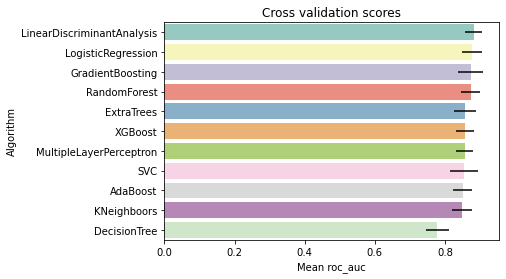

In [55]:
# Test differents algorithms 
random_state = 42
classifiers = []
classifiers.append(SVC(random_state=random_state))
classifiers.append(DecisionTreeClassifier(random_state=random_state))
classifiers.append(AdaBoostClassifier(DecisionTreeClassifier(random_state=random_state),random_state=random_state,learning_rate=0.1))
classifiers.append(RandomForestClassifier(random_state=random_state))
classifiers.append(ExtraTreesClassifier(random_state=random_state))
classifiers.append(GradientBoostingClassifier(random_state=random_state))
classifiers.append(MLPClassifier(random_state=random_state))
classifiers.append(KNeighborsClassifier())
classifiers.append(LogisticRegression(random_state = random_state))
classifiers.append(LinearDiscriminantAnalysis())
classifiers.append(XGBClassifier(random_state=random_state))


cv_results = []
for classifier in classifiers :
    cv_results.append(cross_val_score(classifier, X_train, y = y_train, scoring = "roc_auc", cv = kfold, n_jobs=-1))

cv_means = []
cv_std = []
for cv_result in cv_results:
    cv_means.append(cv_result.mean())
    cv_std.append(cv_result.std())

cv_res = pd.DataFrame({"CrossValMeans":cv_means,"CrossValerrors": cv_std,"Algorithm":["SVC","DecisionTree","AdaBoost",
"RandomForest","ExtraTrees","GradientBoosting","MultipleLayerPerceptron","KNeighboors","LogisticRegression","LinearDiscriminantAnalysis","XGBoost"]})
cv_res = cv_res.sort_values(by=['CrossValMeans'], ascending=False)
g = sns.barplot("CrossValMeans","Algorithm",data = cv_res, palette="Set3",orient = "h",**{'xerr':cv_std})
g.set_xlabel("Mean roc_auc")
g = g.set_title("Cross validation scores")


In [56]:
cv_res = cv_res.sort_values(by=['CrossValMeans'], ascending=False)
cv_res

,CrossValMeans,CrossValerrors,Algorithm
9,0.88,0.03,LinearDiscriminantAnalysis
8,0.88,0.03,LogisticRegression
5,0.87,0.03,GradientBoosting
3,0.87,0.03,RandomForest
4,0.86,0.03,ExtraTrees
10,0.86,0.03,XGBoost
6,0.86,0.02,MultipleLayerPerceptron
0,0.85,0.02,SVC
2,0.85,0.04,AdaBoost
7,0.85,0.04,KNeighboors


I decide to choose: SVC, RandomForest, GradientBoosting, KNN and logistic Regression, XGBoost, for further fine-tunning and the ensemble modeling

### Hyperparameter tunning for best models
grid search optimization for the classifiers

#### SVM

In [57]:
### SVC classifier
svm = SVC(probability=True)
svm_param_grid = {'kernel': ['rbf'], 
                  'gamma': [ 0.0001, 0.001, 0.01, 0.1, 1],
                  'C': [1, 10, 50, 100,200,300,500,700,1000]}

grid_svm = GridSearchCV(svm, param_grid = svm_param_grid, cv=kfold, scoring="roc_auc", n_jobs=-1, verbose = 1)
grid_svm.fit(X_train,y_train)

Fitting 5 folds for each of 45 candidates, totalling 225 fits


GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=None, shuffle=False),
             estimator=SVC(probability=True), n_jobs=-1,
             param_grid={'C': [1, 10, 50, 100, 200, 300, 500, 700, 1000],
                         'gamma': [0.0001, 0.001, 0.01, 0.1, 1],
                         'kernel': ['rbf']},
             scoring='roc_auc', verbose=1)

In [58]:
svm_best = grid_svm.best_estimator_
# Best score
print('Best Score:', grid_svm.best_score_)
print('Best parameters set: \n', grid_svm.best_params_)

Best Score: 0.871152301489292
Best parameters set: 
 {'C': 1, 'gamma': 0.001, 'kernel': 'rbf'}


In [59]:
y_pred_svm = svm_best.predict(X_test)
y_prob_svm = svm_best.predict_proba(X_test)[:,1]

#### Random Forest

In [60]:
### SVC classifier
rf = RandomForestClassifier(n_estimators=20, criterion="entropy", random_state=42)
svm_param_grid = {'kernel': ['rbf'], 
                  'gamma': [ 0.001, 0.01, 0.1, 1],
                  'C': [1, 10, 50, 100,200,300, 1000]}
rf_param_grid = {
    "max_features": range(1,10),
    "min_samples_split": range(1,10),
    "min_samples_leaf": range(1,10),
}

grid_rf = GridSearchCV(rf, param_grid = rf_param_grid, cv=kfold, scoring="roc_auc", n_jobs=-1, verbose = 1)
grid_rf.fit(X_train,y_train)

Fitting 5 folds for each of 729 candidates, totalling 3645 fits


GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=None, shuffle=False),
             estimator=RandomForestClassifier(criterion='entropy',
                                              n_estimators=20,
                                              random_state=42),
             n_jobs=-1,
             param_grid={'max_features': range(1, 10),
                         'min_samples_leaf': range(1, 10),
                         'min_samples_split': range(1, 10)},
             scoring='roc_auc', verbose=1)

In [61]:
rf_best = grid_rf.best_estimator_
# Best score
print('Best Score:', grid_rf.best_score_)
print('Best parameters set: \n', grid_rf.best_params_)

Best Score: 0.8871176630463464
Best parameters set: 
 {'max_features': 4, 'min_samples_leaf': 1, 'min_samples_split': 9}


In [62]:
y_pred_rf = rf_best.predict(X_test)
y_prob_rf = rf_best.predict_proba(X_test)[:,1]

#### KNN

In [63]:
### KNN classifier
knn = KNeighborsClassifier()
knn_param_grid = {
    'n_neighbors': range(1,50),
    'weights': ['uniform','distance']
}

grid_knn = GridSearchCV(knn, param_grid = knn_param_grid, cv=kfold, scoring="roc_auc", n_jobs=-1, verbose = 1)
grid_knn.fit(X_train,y_train)

Fitting 5 folds for each of 98 candidates, totalling 490 fits


GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=None, shuffle=False),
             estimator=KNeighborsClassifier(), n_jobs=-1,
             param_grid={'n_neighbors': range(1, 50),
                         'weights': ['uniform', 'distance']},
             scoring='roc_auc', verbose=1)

In [64]:
knn_best = grid_knn.best_estimator_
# Best score
print('Best Score:', grid_knn.best_score_)
print('Best parameters set: \n', grid_knn.best_params_)

Best Score: 0.8591198690140697
Best parameters set: 
 {'n_neighbors': 18, 'weights': 'uniform'}


In [65]:
y_pred_knn = knn_best.predict(X_test)
y_prob_knn = knn_best.predict_proba(X_test)[:,1]

#### Logistic Regression 

In [66]:
### Logistic Regression classifier

lr = LogisticRegression()
C_grid = 0.001*10**(np.arange(0,1.01,0.01)*3)
lr_param_grid  = {
    'penalty': ['l1', 'l2'], 
    'C': C_grid
}

grid_lr = GridSearchCV(lr, lr_param_grid, scoring='roc_auc')
grid_lr.fit(X_train, y_train)

GridSearchCV(estimator=LogisticRegression(),
             param_grid={'C': array([0.001     , 0.00107152, 0.00114815, 0.00123027, 0.00131826,
       0.00141254, 0.00151356, 0.00162181, 0.0017378 , 0.00186209,
       0.00199526, 0.00213796, 0.00229087, 0.00245471, 0.00263027,
       0.00281838, 0.00301995, 0.00323594, 0.00346737, 0.00371535,
       0.00398107, 0.0042658 , 0.00457088, 0.00489779, 0.00524807,
       0.00562341, 0.00...
       0.12589254, 0.13489629, 0.14454398, 0.15488166, 0.16595869,
       0.17782794, 0.19054607, 0.20417379, 0.21877616, 0.23442288,
       0.25118864, 0.26915348, 0.28840315, 0.30902954, 0.33113112,
       0.35481339, 0.3801894 , 0.40738028, 0.43651583, 0.46773514,
       0.50118723, 0.5370318 , 0.57543994, 0.616595  , 0.66069345,
       0.70794578, 0.75857758, 0.81283052, 0.87096359, 0.9332543 ,
       1.        ]),
                         'penalty': ['l1', 'l2']},
             scoring='roc_auc')

In [67]:
lr_best = grid_lr.best_estimator_
# Best score
print('Best Score:', grid_lr.best_score_)
print('Best parameters set: \n', grid_lr.best_params_)

Best Score: 0.8821458841286429
Best parameters set: 
 {'C': 0.058884365535558904, 'penalty': 'l2'}


In [68]:
y_pred_lr = lr_best.predict(X_test)
y_prob_lr = lr_best.predict_proba(X_test)[:,1]

#### Gradient Boosting

In [69]:
# Gradient boosting tunning
gb = GradientBoostingClassifier(random_state=random_state)
gb_param_grid = {'loss' : ["deviance"],
              'n_estimators' : [5, 10,20,50],
              'learning_rate': [0.5, 0.4, 0.3, 0.2, 0.1],
              'max_depth': range(1,10, 2),
              'min_samples_leaf': [5, 10, 25, 50],
              'max_features': [0.5, 0.25, 0.3, 0.1] 
              }

grid_gb = GridSearchCV(gb,param_grid = gb_param_grid, cv=kfold, scoring="roc_auc", n_jobs= 4, verbose = 1)

grid_gb.fit(X_train,y_train)

Fitting 5 folds for each of 1600 candidates, totalling 8000 fits


GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=None, shuffle=False),
             estimator=GradientBoostingClassifier(random_state=42), n_jobs=4,
             param_grid={'learning_rate': [0.5, 0.4, 0.3, 0.2, 0.1],
                         'loss': ['deviance'], 'max_depth': range(1, 10, 2),
                         'max_features': [0.5, 0.25, 0.3, 0.1],
                         'min_samples_leaf': [5, 10, 25, 50],
                         'n_estimators': [5, 10, 20, 50]},
             scoring='roc_auc', verbose=1)

In [70]:
gb_best = grid_gb.best_estimator_
# Best score
print('Best Score:', grid_gb.best_score_)
print('Best parameters set: \n', grid_gb.best_params_)

Best Score: 0.8900238935858058
Best parameters set: 
 {'learning_rate': 0.1, 'loss': 'deviance', 'max_depth': 9, 'max_features': 0.25, 'min_samples_leaf': 10, 'n_estimators': 5}


In [71]:
y_pred_gb = gb_best.predict(X_test)
y_prob_gb = gb_best.predict_proba(X_test)[:,1]

#### XGBoost

In [72]:
# XGboost tunning
xgb = GradientBoostingClassifier(random_state=random_state)

#xgb.get_params().keys()
xgb_param_grid = {
    'learning_rate': [0.001, 0.01, 0.025,0.05,0.1], 
    'max_depth': range(1,10),
    'subsample': [0.01,0.05, 0.1, 0.25,0.5,1.0, 1.5, 2]
}
grid_xgb = GridSearchCV(xgb, param_grid = xgb_param_grid, cv=kfold, scoring="roc_auc", n_jobs= 4, verbose = 1)

grid_xgb.fit(X_train,y_train)

Fitting 5 folds for each of 360 candidates, totalling 1800 fits


GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=None, shuffle=False),
             estimator=GradientBoostingClassifier(random_state=42), n_jobs=4,
             param_grid={'learning_rate': [0.001, 0.01, 0.025, 0.05, 0.1],
                         'max_depth': range(1, 10),
                         'subsample': [0.01, 0.05, 0.1, 0.25, 0.5, 1.0, 1.5,
                                       2]},
             scoring='roc_auc', verbose=1)

In [73]:
xgb_best = grid_xgb.best_estimator_
# Best score
print('Best Score:', grid_xgb.best_score_)
print('Best parameters set: \n', grid_xgb.best_params_)

Best Score: 0.8854110593922506
Best parameters set: 
 {'learning_rate': 0.001, 'max_depth': 6, 'subsample': 0.5}


In [74]:
y_pred_xgb = xgb_best.predict(X_test)
y_prob_xgb = xgb_best.predict_proba(X_test)[:,1]

#### Linear Discriminant Analysis

In [75]:
# LDA tunning
LDA = LinearDiscriminantAnalysis()
#lda.get_params().keys()
## Search grid for optimal parameters
lda_param_grid = {"solver" : ["svd"],
              "tol" : [0.00001,0.0001,0.0002,0.0003]}


grid_lda = GridSearchCV(LDA, param_grid = lda_param_grid, cv=kfold, scoring="roc_auc", n_jobs= 4, verbose = 1)
grid_lda.fit(X_train,y_train)

Fitting 5 folds for each of 4 candidates, totalling 20 fits


GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=None, shuffle=False),
             estimator=LinearDiscriminantAnalysis(), n_jobs=4,
             param_grid={'solver': ['svd'],
                         'tol': [1e-05, 0.0001, 0.0002, 0.0003]},
             scoring='roc_auc', verbose=1)

In [76]:
lda_best = grid_lda.best_estimator_
# Best score
print('Best Score:', grid_lda.best_score_)
print('Best parameters set: \n', grid_lda.best_params_)

Best Score: 0.8819394572686108
Best parameters set: 
 {'solver': 'svd', 'tol': 1e-05}


In [77]:
y_pred_lda = lda_best.predict(X_test)
y_prob_lda = lda_best.predict_proba(X_test)[:,1]

In [78]:
# print a summary of the scores
def print_grid_search_metrics(gs):
    print("Best score: %0.3f" % gs.best_score_)
    print("Best parameters set:")
    best_parameters = gs.best_params_
    for param_name in sorted(parameters.keys()):
        print("\t%s: %r" % (param_name, best_parameters[param_name]))

### Comparing the best models
I will take a closer look of the selected models: logistic Regression, Random Forest, Gradient Boosting, KNN, XGBoost and SVM. 

- Learning Curve
- Confusion Matrix

In [79]:
"""
print_grid_search_metrics(grid_svm)
print_grid_search_metrics(grid_rf)
print_grid_search_metrics(grid_gb)
print_grid_search_metrics(grid_knn)
print_grid_search_metrics(grid_lr)
print_grid_search_metrics(grid_xgb)
print_grid_search_metrics(grid_lda)
"""

'\nprint_grid_search_metrics(grid_svm)\nprint_grid_search_metrics(grid_rf)\nprint_grid_search_metrics(grid_gb)\nprint_grid_search_metrics(grid_knn)\nprint_grid_search_metrics(grid_lr)\nprint_grid_search_metrics(grid_xgb)\nprint_grid_search_metrics(grid_lda)\n'

#### Plot learning curves
Learning curves are a good way to see the overfitting effect on the training set and the effect of the training size on the accuracy.

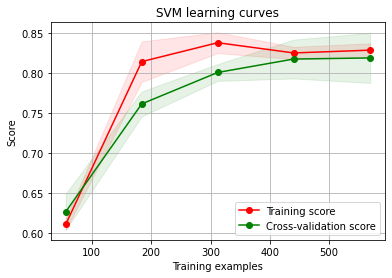

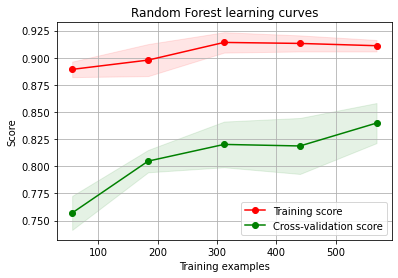

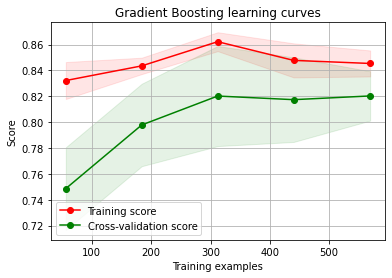

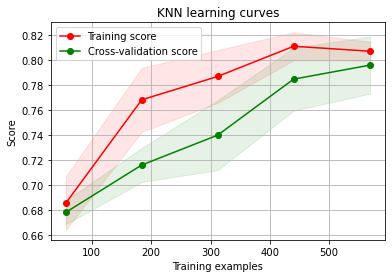

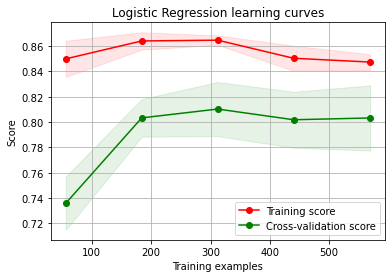

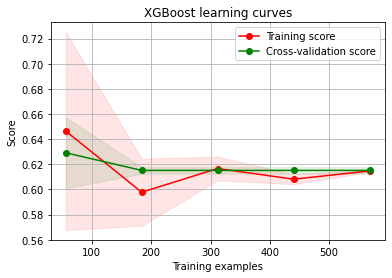

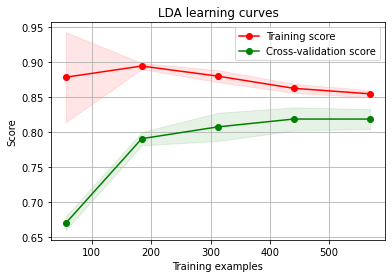

In [80]:
# Plot learning curves
#grid_svm, grid_rf, grid_gb, grid_knn, grid_lr, grid_xgb

def plot_learning_curve(estimator, title, X, y, ylim=None, cv=None,
                        n_jobs=-1, train_sizes=np.linspace(.1, 1.0, 5)):
    """Generate a simple plot of the test and training learning curve"""
    plt.figure()
    plt.title(title)
    if ylim is not None:
        plt.ylim(*ylim)
    plt.xlabel("Training examples")
    plt.ylabel("Score")
    train_sizes, train_scores, test_scores = learning_curve(
        estimator, X, y, cv=cv, n_jobs=n_jobs, train_sizes=train_sizes)
    train_scores_mean = np.mean(train_scores, axis=1)
    train_scores_std = np.std(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)
    test_scores_std = np.std(test_scores, axis=1)
    plt.grid()

    plt.fill_between(train_sizes, train_scores_mean - train_scores_std,
                     train_scores_mean + train_scores_std, alpha=0.1,
                     color="r")
    plt.fill_between(train_sizes, test_scores_mean - test_scores_std,
                     test_scores_mean + test_scores_std, alpha=0.1, color="g")
    plt.plot(train_sizes, train_scores_mean, 'o-', color="r",
             label="Training score")
    plt.plot(train_sizes, test_scores_mean, 'o-', color="g",
             label="Cross-validation score")

    plt.legend(loc="best")
    return plt

g = plot_learning_curve(grid_svm.best_estimator_,"SVM learning curves",X_train,y_train,cv=kfold)
g = plot_learning_curve(grid_rf.best_estimator_,"Random Forest learning curves",X_train,y_train,cv=kfold)
g = plot_learning_curve(grid_gb.best_estimator_,"Gradient Boosting learning curves",X_train,y_train,cv=kfold)
g = plot_learning_curve(grid_knn.best_estimator_,"KNN learning curves",X_train,y_train,cv=kfold)
g = plot_learning_curve(grid_lr.best_estimator_,"Logistic Regression learning curves",X_train,y_train,cv=kfold)
g = plot_learning_curve(grid_xgb.best_estimator_,"XGBoost learning curves",X_train,y_train,cv=kfold)
g = plot_learning_curve(grid_lda.best_estimator_,"LDA learning curves",X_train,y_train,cv=kfold)

In [81]:
## Calculate Confusion Matrix (Precision, Recall, Accuracy)

In [82]:
from sklearn.metrics import confusion_matrix, roc_curve, roc_auc_score, accuracy_score, precision_score, recall_score

def cal_evaluation(classifier, cm, auc):
    tn = cm[0][0]
    fp = cm[0][1]
    fn = cm[1][0]
    tp = cm[1][1]
    accuracy  = (tp + tn) / (tp + fp + fn + tn + 0.0)
    precision = tp / (tp + fp + 0.0)
    recall = tp / (tp + fn + 0.0)
    f1 = 2 * precision * recall / (precision + recall)
    print(classifier)
    print("Accuracy is " + str(accuracy))
    print("Precision is " + str(precision))
    print("Recall is " + str(recall))
    print("F1 score is " + str(f1))
    print("ROC AUC is " + str(auc))

def draw_confusion_matrices(confusion_matricies):
    class_names = ['Not Survived','Survived']
    for x in confusion_matrices:
        classifier, cm, auc = x[0], x[1], x[2]
        cal_evaluation(classifier, cm, auc)
        fig = plt.figure()
        ax = fig.add_subplot(111)
        cax = ax.matshow(cm, interpolation='nearest',cmap=plt.get_cmap('Reds'))
        plt.title('Confusion matrix for {}'.format(classifier))
        fig.colorbar(cax)
        ax.set_xticklabels([''] + class_names)
        ax.set_yticklabels([''] + class_names)
        plt.xlabel('Predicted')
        plt.ylabel('True')
        plt.show()

[0 1]
Gradient Boosting
Accuracy is 0.7877094972067039
Precision is 0.8260869565217391
Recall is 0.5588235294117647
F1 score is 0.6666666666666667
ROC AUC is 0.8328696343402225


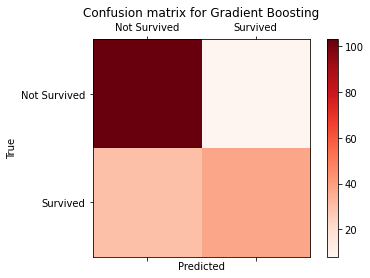

Logisitic Regression
Accuracy is 0.7988826815642458
Precision is 0.7352941176470589
Recall is 0.7352941176470589
F1 score is 0.735294117647059
ROC AUC is 0.835519342872284


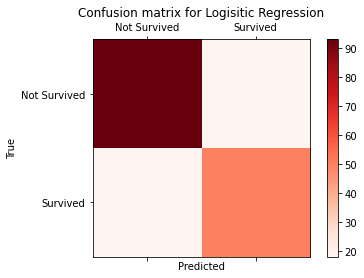

K-Nearest-Neighbors
Accuracy is 0.7318435754189944
Precision is 0.7
Recall is 0.5147058823529411
F1 score is 0.5932203389830508
ROC AUC is 0.7952437731849497


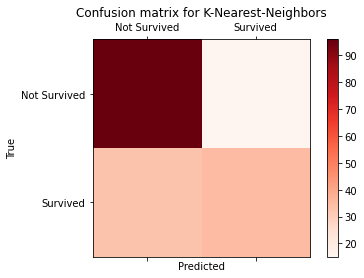

Random Forest
Accuracy is 0.7821229050279329
Precision is 0.7230769230769231
Recall is 0.6911764705882353
F1 score is 0.7067669172932332
ROC AUC is 0.8494965553789084


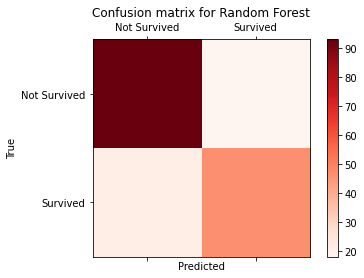

Support Vector Machine
Accuracy is 0.8156424581005587
Precision is 0.7966101694915254
Recall is 0.6911764705882353
F1 score is 0.7401574803149606
ROC AUC is 0.8202835188129306


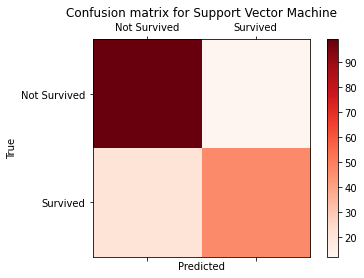

XGBoost Classifier
Accuracy is 0.6201117318435754
Precision is nan
Recall is 0.0
F1 score is nan
ROC AUC is 0.8400238473767886


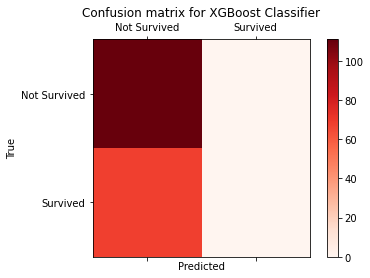

LDA Classifier
Accuracy is 0.8268156424581006
Precision is 0.7846153846153846
Recall is 0.75
F1 score is 0.7669172932330828
ROC AUC is 0.8461181770005299


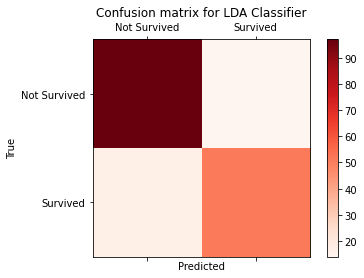

In [83]:
%matplotlib inline

y = np.array(y)
class_names = np.unique(y)
print(class_names)

confusion_matrices = [
    ("Gradient Boosting", confusion_matrix(y_test, y_pred_gb), roc_auc_score(y_test, y_prob_gb)),
    ("Logisitic Regression", confusion_matrix(y_test, y_pred_lr), roc_auc_score(y_test, y_prob_lr)),
    ("K-Nearest-Neighbors", confusion_matrix(y_test, y_pred_knn), roc_auc_score(y_test, y_prob_knn)),
    ("Random Forest", confusion_matrix(y_test, y_pred_rf), roc_auc_score(y_test, y_prob_rf)),
    ("Support Vector Machine", confusion_matrix(y_test, y_pred_svm), roc_auc_score(y_test, y_prob_svm)),
    ("XGBoost Classifier", confusion_matrix(y_test, y_pred_xgb), roc_auc_score(y_test, y_prob_xgb)),
    ("LDA Classifier", confusion_matrix(y_test, y_pred_lda), roc_auc_score(y_test, y_prob_lda))
]

draw_confusion_matrices(confusion_matrices)

## Feature importance of tree based classifiers
In order to see the most informative features for the prediction of passengers survival, i displayed the feature importance for the tree based classifiers

In [84]:
"""
forest = RandomForestClassifier()
forest.fit(X_train, y_train)
importances = forest.feature_importances_
# Print the feature ranking
print("Feature importance ranking by Random Forest Model:")
for k,v in sorted(zip(map(lambda x: round(x, 4), importances), X_train.columns), reverse=True):
    print(v + ": " + str(k))
"""

'\nforest = RandomForestClassifier()\nforest.fit(X_train, y_train)\nimportances = forest.feature_importances_\n# Print the feature ranking\nprint("Feature importance ranking by Random Forest Model:")\nfor k,v in sorted(zip(map(lambda x: round(x, 4), importances), X_train.columns), reverse=True):\n    print(v + ": " + str(k))\n'

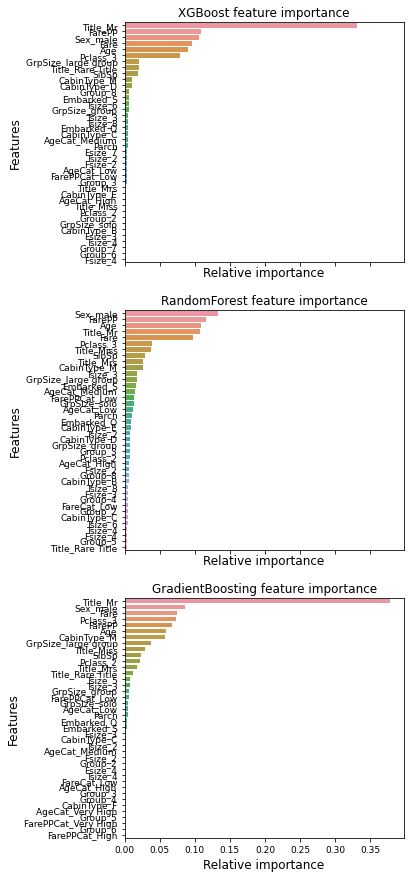

In [85]:
#nrows = ncols = 2
nrows = 3
ncols = 1
fig, axes = plt.subplots(nrows = nrows, ncols = ncols, sharex="all", figsize=(5,15))

names_classifiers = [("XGBoost", xgb_best),("RandomForest",rf_best),("GradientBoosting",gb_best),("GradientBoosting",gb_best)]

nclassifier = 0
for row in range(nrows):
    name = names_classifiers[nclassifier][0]
    classifier = names_classifiers[nclassifier][1]
    indices = np.argsort(classifier.feature_importances_)[::-1][:40]
    g = sns.barplot(y=X_train.columns[indices][:40],x = classifier.feature_importances_[indices][:40] , orient='h',ax=axes[row])
    g.set_xlabel("Relative importance",fontsize=12)
    g.set_ylabel("Features",fontsize=12)
    g.tick_params(labelsize=9)
    g.set_title(name + " feature importance")
    nclassifier += 1

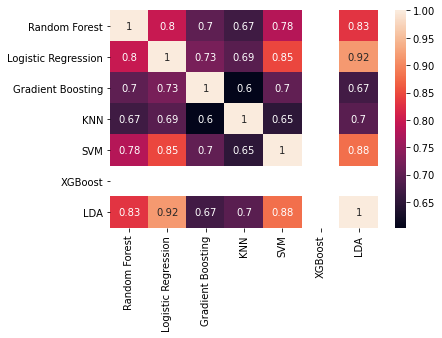

In [86]:
# Concatenate all classifier results

test_rf = pd.Series(rf_best.predict(X_test), name="Random Forest")
test_lr = pd.Series(lr_best.predict(X_test), name="Logistic Regression")
test_gb = pd.Series(gb_best.predict(X_test), name="Gradient Boosting")
test_knn = pd.Series(knn_best.predict(X_test), name="KNN")
test_svm = pd.Series(svm_best.predict(X_test), name="SVM")
test_xgb = pd.Series(xgb_best.predict(X_test), name="XGBoost")
test_lda = pd.Series(lda_best.predict(X_test), name="LDA")


ensemble_results = pd.concat([test_rf, test_lr,test_gb,test_knn, test_svm, test_xgb, test_lda],axis=1)

g= sns.heatmap(ensemble_results.corr(),annot=True)

### Ensemble modeling

I chosed a voting classifier to combine the predictions coming from the 7 classifiers.

I preferred to pass the argument "soft" to the voting parameter to take into account the probability of each vote.

In [87]:
votingC = VotingClassifier(estimators=[('rf', rf_best), ('lr',lr_best),('knn', knn_best),
('svm', svm_best), ('gb',gb_best),('xgb',xgb_best),('lda',lda_best)], voting='soft', n_jobs=4)
votingC = votingC.fit(X_train, y_train)

In [88]:
y_pred_voting = votingC.predict(X_test)
y_prob_voting = votingC.predict_proba(X_test)[:,1]

Ensemble modeling
Accuracy is 0.8212290502793296
Precision is 0.78125
Recall is 0.7352941176470589
F1 score is 0.7575757575757576
ROC AUC is 0.8474430312665606


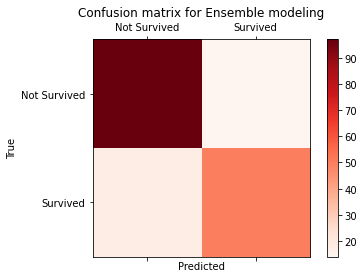

In [89]:
confusion_matrices = [
    ("Ensemble modeling", confusion_matrix(y_test, y_pred_voting), roc_auc_score(y_test, y_prob_voting))   
]
draw_confusion_matrices(confusion_matrices)

The AUROC score of is smaller than the XGBoost score. Therefore, I will use XGboost for the final prediction. 

## LDA for predictions
Again, the goal is to predict survival. 

I will display the LDA results below, as a reminder. 

LDA
Accuracy is 0.8268156424581006
Precision is 0.7846153846153846
Recall is 0.75
F1 score is 0.7669172932330828
ROC AUC is 0.8461181770005299


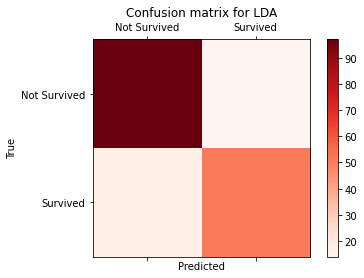

In [90]:
confusion_matrices = [
    ("LDA", confusion_matrix(y_test, y_pred_lda), roc_auc_score(y_test, y_prob_lda))
]

draw_confusion_matrices(confusion_matrices)

Next, I will try to determine the optimal threshold. As true positive rate and recall are actually equal, therefore, one can use a lower threshold(<0.5) to achieve higher recall rate.

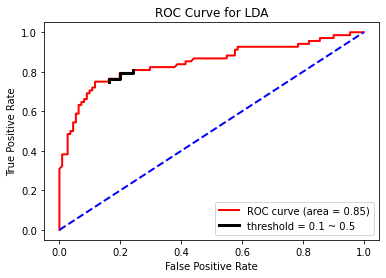

In [91]:
# make the ROC curve
fpr, tpr, thresh = roc_curve(y_test, y_prob_lda, pos_label=1)
roc_auc = roc_auc_score(y_test, y_prob_lda)

# These are the points at threshold = 0.1~0.5
x1 = fpr[(thresh <= 0.5) & (thresh >= 0.1)] 
x2 = tpr[(thresh <= 0.5) & (thresh >= 0.1)]

fig = plt.figure()
plt.plot(fpr, tpr, color='r', lw=2, label='ROC curve (area = {:.2f})'.format(roc_auc))
plt.plot([0, 1], [0, 1], color='b', lw=2, linestyle='--')
plt.plot(x1, x2, color='k', lw=3, label='threshold = 0.1 ~ 0.5')
plt.xlim([-0.05, 1.05])
plt.ylim([-0.05, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for LDA')
plt.legend(loc="lower right")
plt.show()

In [92]:
acc_grid = np.zeros(thresh.shape)
prec_grid = np.zeros(thresh.shape)
recall_grid = np.zeros(thresh.shape)
TP_grid = np.zeros(thresh.shape)
FP_grid = np.zeros(thresh.shape)
FN_grid = np.zeros(thresh.shape)

for i in range(thresh.shape[0]):
    cm = confusion_matrix(y_test, y_prob_rf >= thresh[i])
    acc_grid[i] = accuracy_score(y_test, y_prob_rf >= thresh[i])
    prec_grid[i] = precision_score(y_test, y_prob_rf >= thresh[i])
    recall_grid[i] = recall_score(y_test, y_prob_rf >= thresh[i])
    TP_grid[i] = cm[1][1]
    FP_grid[i] = cm[0][1]
    FN_grid[i] = cm[1][0]

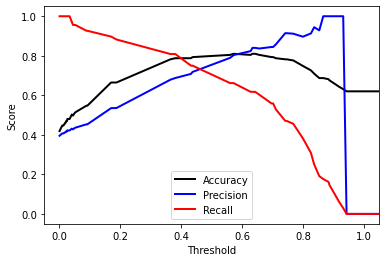

In [93]:
fig = plt.figure()
plt.plot(thresh, acc_grid, color='k', lw=2, label='Accuracy')
plt.plot(thresh, prec_grid, color='b', lw=2, label='Precision')
plt.plot(thresh, recall_grid, color='r', lw=2, label='Recall')
plt.xlim([-0.05, 1.05])
plt.ylim([-0.05, 1.05])
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.legend(loc="lower center")
plt.show()

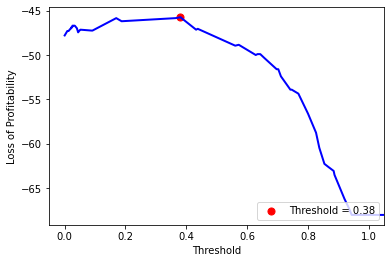

In [94]:
P = 0.5 # The chance a customer who was going to drop would take the special offer
loss = TP_grid*P*(-0.1) + TP_grid*(1-P)*(-1) + FN_grid*(-1) + FP_grid*(-0.1)
thresh_best = thresh[loss == max(loss)][0]
    
fig = plt.figure()
plt.plot(thresh, loss, color='b', lw=2)
plt.scatter([thresh_best], [max(loss)], color='r', s=50, label='Threshold = {:.2f}'.format(thresh_best))
plt.xlim([-0.05, 1.05])
plt.xlabel('Threshold')
plt.ylabel('Loss of Profitability')
plt.legend(loc="lower right")
plt.show()

LDA
Accuracy is 0.7932960893854749
Precision is 0.7123287671232876
Recall is 0.7647058823529411
F1 score is 0.7375886524822695
ROC AUC is 0.8461181770005299


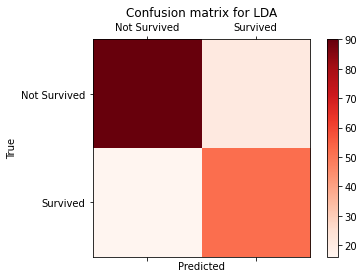

In [95]:
y_pred_lda_new = y_prob_lda > thresh_best

confusion_matrices = [
    ("LDA", confusion_matrix(y_test, y_pred_lda_new), roc_auc_score(y_test, y_prob_lda))
]

draw_confusion_matrices(confusion_matrices)

In [96]:
#test1=test.copy()
test=test.sort_values(by='PassengerId', ascending=False)
test.head()

,Age,SibSp,Parch,Fare,AgeCat_Low,AgeCat_Medium,AgeCat_High,AgeCat_Very High,Title_Miss,Title_Mr,Title_Mrs,Title_Rare Title,CabinType_B,CabinType_C,CabinType_D,CabinType_E,CabinType_F,CabinType_G,CabinType_M,CabinType_T,Embarked_Q,Embarked_S,FareCat_Low,FareCat_Medium,FareCat_High,FareCat_Very High,Sex_male,Pclass_2,Pclass_3,Fsize_2,Fsize_3,Fsize_4,Fsize_5,Fsize_6,Fsize_7,Fsize_8,Fsize_11,Tsize_2,Tsize_3,Tsize_4,Tsize_5,Tsize_6,Tsize_7,Tsize_8,Tsize_11,FarePP,FarePPCat_Low,FarePPCat_Medium,FarePPCat_High,FarePPCat_Very High,GrpSize_group,GrpSize_large group,GrpSize_solo,Group_2,Group_3,Group_4,Group_5,Group_6,Group_7,Group_8,Group_11
PassengerId,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1309,6.00,1,1,22.36,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,1,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,7.45,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0
1308,26.00,0,0,8.05,1,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,8.05,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0
1307,38.50,0,0,7.25,0,1,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,7.25,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0
1306,39.00,0,0,108.90,0,1,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,36.30,1,0,0,0,1,0,0,0,1,0,0,0,0,0,0
1305,26.00,0,0,8.05,1,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,8.05,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0


In [97]:
from sklearn.preprocessing import StandardScaler
scaled_test = StandardScaler().fit_transform(test.values)
scaled_test = pd.DataFrame(scaled_test, index=test.index, columns=test.columns)
scaled_test.head()

,Age,SibSp,Parch,Fare,AgeCat_Low,AgeCat_Medium,AgeCat_High,AgeCat_Very High,Title_Miss,Title_Mr,Title_Mrs,Title_Rare Title,CabinType_B,CabinType_C,CabinType_D,CabinType_E,CabinType_F,CabinType_G,CabinType_M,CabinType_T,Embarked_Q,Embarked_S,FareCat_Low,FareCat_Medium,FareCat_High,FareCat_Very High,Sex_male,Pclass_2,Pclass_3,Fsize_2,Fsize_3,Fsize_4,Fsize_5,Fsize_6,Fsize_7,Fsize_8,Fsize_11,Tsize_2,Tsize_3,Tsize_4,Tsize_5,Tsize_6,Tsize_7,Tsize_8,Tsize_11,FarePP,FarePPCat_Low,FarePPCat_Medium,FarePPCat_High,FarePPCat_Very High,GrpSize_group,GrpSize_large group,GrpSize_solo,Group_2,Group_3,Group_4,Group_5,Group_6,Group_7,Group_8,Group_11
PassengerId,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1309,-1.77,0.62,0.62,-0.24,-1.22,-0.52,-0.31,-0.07,-0.48,-1.16,-0.46,-0.13,-0.21,-0.30,-0.18,-0.15,-0.14,-0.05,0.53,0.00,-0.35,-1.35,-0.18,-0.21,0.00,-0.05,0.76,-0.53,0.96,-0.46,2.52,-0.19,-0.13,-0.09,-0.10,-0.07,-0.10,-0.50,2.84,-0.22,-0.19,-0.11,-0.16,-0.09,-0.10,-0.54,-0.46,-0.12,-0.07,-0.05,2.02,-0.32,-1.03,-0.49,2.47,-0.24,-0.19,-0.11,-0.17,-0.09,-0.10
1308,-0.26,-0.50,-0.40,-0.50,0.82,-0.52,-0.31,-0.07,-0.48,0.86,-0.46,-0.13,-0.21,-0.30,-0.18,-0.15,-0.14,-0.05,0.53,0.00,-0.35,0.74,-0.18,-0.21,0.00,-0.05,0.76,-0.53,0.96,-0.46,-0.40,-0.19,-0.13,-0.09,-0.10,-0.07,-0.10,-0.50,-0.35,-0.22,-0.19,-0.11,-0.16,-0.09,-0.10,-0.50,-0.46,-0.12,-0.07,-0.05,-0.49,-0.32,0.97,-0.49,-0.41,-0.24,-0.19,-0.11,-0.17,-0.09,-0.10
1307,0.69,-0.50,-0.40,-0.51,-1.22,1.91,-0.31,-0.07,-0.48,0.86,-0.46,-0.13,-0.21,-0.30,-0.18,-0.15,-0.14,-0.05,0.53,0.00,-0.35,0.74,-0.18,-0.21,0.00,-0.05,0.76,-0.53,0.96,-0.46,-0.40,-0.19,-0.13,-0.09,-0.10,-0.07,-0.10,-0.50,-0.35,-0.22,-0.19,-0.11,-0.16,-0.09,-0.10,-0.56,-0.46,-0.12,-0.07,-0.05,-0.49,-0.32,0.97,-0.49,-0.41,-0.24,-0.19,-0.11,-0.17,-0.09,-0.10
1306,0.73,-0.50,-0.40,1.31,-1.22,1.91,-0.31,-0.07,-0.48,-1.16,-0.46,7.66,-0.21,3.31,-0.18,-0.15,-0.14,-0.05,-1.90,0.00,-0.35,-1.35,5.58,-0.21,0.00,-0.05,-1.32,-0.53,-1.04,-0.46,-0.40,-0.19,-0.13,-0.09,-0.10,-0.07,-0.10,-0.50,2.84,-0.22,-0.19,-0.11,-0.16,-0.09,-0.10,1.51,2.16,-0.12,-0.07,-0.05,2.02,-0.32,-1.03,-0.49,2.47,-0.24,-0.19,-0.11,-0.17,-0.09,-0.10
1305,-0.26,-0.50,-0.40,-0.50,0.82,-0.52,-0.31,-0.07,-0.48,0.86,-0.46,-0.13,-0.21,-0.30,-0.18,-0.15,-0.14,-0.05,0.53,0.00,-0.35,0.74,-0.18,-0.21,0.00,-0.05,0.76,-0.53,0.96,-0.46,-0.40,-0.19,-0.13,-0.09,-0.10,-0.07,-0.10,-0.50,-0.35,-0.22,-0.19,-0.11,-0.16,-0.09,-0.10,-0.50,-0.46,-0.12,-0.07,-0.05,-0.49,-0.32,0.97,-0.49,-0.41,-0.24,-0.19,-0.11,-0.17,-0.09,-0.10


In [98]:
y_pred_lda = lda_best.predict(scaled_test)
y_prob_lda = lda_best.predict_proba(scaled_test)[:,1]

In [99]:
scaled_test['Survived']=y_pred_lda
scaled_test.head()

,Age,SibSp,Parch,Fare,AgeCat_Low,AgeCat_Medium,AgeCat_High,AgeCat_Very High,Title_Miss,Title_Mr,Title_Mrs,Title_Rare Title,CabinType_B,CabinType_C,CabinType_D,CabinType_E,CabinType_F,CabinType_G,CabinType_M,CabinType_T,Embarked_Q,Embarked_S,FareCat_Low,FareCat_Medium,FareCat_High,FareCat_Very High,Sex_male,Pclass_2,Pclass_3,Fsize_2,Fsize_3,Fsize_4,Fsize_5,Fsize_6,Fsize_7,Fsize_8,Fsize_11,Tsize_2,Tsize_3,Tsize_4,Tsize_5,Tsize_6,Tsize_7,Tsize_8,Tsize_11,FarePP,FarePPCat_Low,FarePPCat_Medium,FarePPCat_High,FarePPCat_Very High,GrpSize_group,GrpSize_large group,GrpSize_solo,Group_2,Group_3,Group_4,Group_5,Group_6,Group_7,Group_8,Group_11,Survived
PassengerId,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1309,-1.77,0.62,0.62,-0.24,-1.22,-0.52,-0.31,-0.07,-0.48,-1.16,-0.46,-0.13,-0.21,-0.30,-0.18,-0.15,-0.14,-0.05,0.53,0.00,-0.35,-1.35,-0.18,-0.21,0.00,-0.05,0.76,-0.53,0.96,-0.46,2.52,-0.19,-0.13,-0.09,-0.10,-0.07,-0.10,-0.50,2.84,-0.22,-0.19,-0.11,-0.16,-0.09,-0.10,-0.54,-0.46,-0.12,-0.07,-0.05,2.02,-0.32,-1.03,-0.49,2.47,-0.24,-0.19,-0.11,-0.17,-0.09,-0.10,1
1308,-0.26,-0.50,-0.40,-0.50,0.82,-0.52,-0.31,-0.07,-0.48,0.86,-0.46,-0.13,-0.21,-0.30,-0.18,-0.15,-0.14,-0.05,0.53,0.00,-0.35,0.74,-0.18,-0.21,0.00,-0.05,0.76,-0.53,0.96,-0.46,-0.40,-0.19,-0.13,-0.09,-0.10,-0.07,-0.10,-0.50,-0.35,-0.22,-0.19,-0.11,-0.16,-0.09,-0.10,-0.50,-0.46,-0.12,-0.07,-0.05,-0.49,-0.32,0.97,-0.49,-0.41,-0.24,-0.19,-0.11,-0.17,-0.09,-0.10,0
1307,0.69,-0.50,-0.40,-0.51,-1.22,1.91,-0.31,-0.07,-0.48,0.86,-0.46,-0.13,-0.21,-0.30,-0.18,-0.15,-0.14,-0.05,0.53,0.00,-0.35,0.74,-0.18,-0.21,0.00,-0.05,0.76,-0.53,0.96,-0.46,-0.40,-0.19,-0.13,-0.09,-0.10,-0.07,-0.10,-0.50,-0.35,-0.22,-0.19,-0.11,-0.16,-0.09,-0.10,-0.56,-0.46,-0.12,-0.07,-0.05,-0.49,-0.32,0.97,-0.49,-0.41,-0.24,-0.19,-0.11,-0.17,-0.09,-0.10,0
1306,0.73,-0.50,-0.40,1.31,-1.22,1.91,-0.31,-0.07,-0.48,-1.16,-0.46,7.66,-0.21,3.31,-0.18,-0.15,-0.14,-0.05,-1.90,0.00,-0.35,-1.35,5.58,-0.21,0.00,-0.05,-1.32,-0.53,-1.04,-0.46,-0.40,-0.19,-0.13,-0.09,-0.10,-0.07,-0.10,-0.50,2.84,-0.22,-0.19,-0.11,-0.16,-0.09,-0.10,1.51,2.16,-0.12,-0.07,-0.05,2.02,-0.32,-1.03,-0.49,2.47,-0.24,-0.19,-0.11,-0.17,-0.09,-0.10,1
1305,-0.26,-0.50,-0.40,-0.50,0.82,-0.52,-0.31,-0.07,-0.48,0.86,-0.46,-0.13,-0.21,-0.30,-0.18,-0.15,-0.14,-0.05,0.53,0.00,-0.35,0.74,-0.18,-0.21,0.00,-0.05,0.76,-0.53,0.96,-0.46,-0.40,-0.19,-0.13,-0.09,-0.10,-0.07,-0.10,-0.50,-0.35,-0.22,-0.19,-0.11,-0.16,-0.09,-0.10,-0.50,-0.46,-0.12,-0.07,-0.05,-0.49,-0.32,0.97,-0.49,-0.41,-0.24,-0.19,-0.11,-0.17,-0.09,-0.10,0


In [100]:
scaled_test=scaled_test.reset_index()
scaled_test.head()

,PassengerId,Age,SibSp,Parch,Fare,AgeCat_Low,AgeCat_Medium,AgeCat_High,AgeCat_Very High,Title_Miss,Title_Mr,Title_Mrs,Title_Rare Title,CabinType_B,CabinType_C,CabinType_D,CabinType_E,CabinType_F,CabinType_G,CabinType_M,CabinType_T,Embarked_Q,Embarked_S,FareCat_Low,FareCat_Medium,FareCat_High,FareCat_Very High,Sex_male,Pclass_2,Pclass_3,Fsize_2,Fsize_3,Fsize_4,Fsize_5,Fsize_6,Fsize_7,Fsize_8,Fsize_11,Tsize_2,Tsize_3,Tsize_4,Tsize_5,Tsize_6,Tsize_7,Tsize_8,Tsize_11,FarePP,FarePPCat_Low,FarePPCat_Medium,FarePPCat_High,FarePPCat_Very High,GrpSize_group,GrpSize_large group,GrpSize_solo,Group_2,Group_3,Group_4,Group_5,Group_6,Group_7,Group_8,Group_11,Survived
0,1309,-1.77,0.62,0.62,-0.24,-1.22,-0.52,-0.31,-0.07,-0.48,-1.16,-0.46,-0.13,-0.21,-0.30,-0.18,-0.15,-0.14,-0.05,0.53,0.00,-0.35,-1.35,-0.18,-0.21,0.00,-0.05,0.76,-0.53,0.96,-0.46,2.52,-0.19,-0.13,-0.09,-0.10,-0.07,-0.10,-0.50,2.84,-0.22,-0.19,-0.11,-0.16,-0.09,-0.10,-0.54,-0.46,-0.12,-0.07,-0.05,2.02,-0.32,-1.03,-0.49,2.47,-0.24,-0.19,-0.11,-0.17,-0.09,-0.10,1
1,1308,-0.26,-0.50,-0.40,-0.50,0.82,-0.52,-0.31,-0.07,-0.48,0.86,-0.46,-0.13,-0.21,-0.30,-0.18,-0.15,-0.14,-0.05,0.53,0.00,-0.35,0.74,-0.18,-0.21,0.00,-0.05,0.76,-0.53,0.96,-0.46,-0.40,-0.19,-0.13,-0.09,-0.10,-0.07,-0.10,-0.50,-0.35,-0.22,-0.19,-0.11,-0.16,-0.09,-0.10,-0.50,-0.46,-0.12,-0.07,-0.05,-0.49,-0.32,0.97,-0.49,-0.41,-0.24,-0.19,-0.11,-0.17,-0.09,-0.10,0
2,1307,0.69,-0.50,-0.40,-0.51,-1.22,1.91,-0.31,-0.07,-0.48,0.86,-0.46,-0.13,-0.21,-0.30,-0.18,-0.15,-0.14,-0.05,0.53,0.00,-0.35,0.74,-0.18,-0.21,0.00,-0.05,0.76,-0.53,0.96,-0.46,-0.40,-0.19,-0.13,-0.09,-0.10,-0.07,-0.10,-0.50,-0.35,-0.22,-0.19,-0.11,-0.16,-0.09,-0.10,-0.56,-0.46,-0.12,-0.07,-0.05,-0.49,-0.32,0.97,-0.49,-0.41,-0.24,-0.19,-0.11,-0.17,-0.09,-0.10,0
3,1306,0.73,-0.50,-0.40,1.31,-1.22,1.91,-0.31,-0.07,-0.48,-1.16,-0.46,7.66,-0.21,3.31,-0.18,-0.15,-0.14,-0.05,-1.90,0.00,-0.35,-1.35,5.58,-0.21,0.00,-0.05,-1.32,-0.53,-1.04,-0.46,-0.40,-0.19,-0.13,-0.09,-0.10,-0.07,-0.10,-0.50,2.84,-0.22,-0.19,-0.11,-0.16,-0.09,-0.10,1.51,2.16,-0.12,-0.07,-0.05,2.02,-0.32,-1.03,-0.49,2.47,-0.24,-0.19,-0.11,-0.17,-0.09,-0.10,1
4,1305,-0.26,-0.50,-0.40,-0.50,0.82,-0.52,-0.31,-0.07,-0.48,0.86,-0.46,-0.13,-0.21,-0.30,-0.18,-0.15,-0.14,-0.05,0.53,0.00,-0.35,0.74,-0.18,-0.21,0.00,-0.05,0.76,-0.53,0.96,-0.46,-0.40,-0.19,-0.13,-0.09,-0.10,-0.07,-0.10,-0.50,-0.35,-0.22,-0.19,-0.11,-0.16,-0.09,-0.10,-0.50,-0.46,-0.12,-0.07,-0.05,-0.49,-0.32,0.97,-0.49,-0.41,-0.24,-0.19,-0.11,-0.17,-0.09,-0.10,0


In [101]:
PassengerId = scaled_test.PassengerId.values
test_preds = scaled_test.Survived.values
submission = pd.DataFrame.from_dict({
    'PassengerId':PassengerId,
    'Survived':test_preds,
})
submission.to_csv('gender_submission.csv', index=False)

In [102]:
submission = pd.read_csv('gender_submission.csv')
submission.head()

,PassengerId,Survived
0,1309,1
1,1308,0
2,1307,0
3,1306,1
4,1305,0
